# Data Cleaning

In [1]:
%reset -f

Imports

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import gc
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

Loading the datasheets

In [3]:
DATA_RAW = Path("../data/raw")

studentInfo = pd.read_csv(DATA_RAW / "studentInfo.csv")
studentVle = pd.read_csv(DATA_RAW / "studentVle.csv")
assessments = pd.read_csv(DATA_RAW / "assessments.csv")
studentAssessment = pd.read_csv(DATA_RAW / "studentAssessment.csv")
courses = pd.read_csv(DATA_RAW / "courses.csv")
vle = pd.read_csv(DATA_RAW / "vle.csv")
studentReg = pd.read_csv(DATA_RAW / "studentRegistration.csv")

### Tables Overview

In [4]:
datasets = {
    "studentInfo": studentInfo,
    "studentVle": studentVle,
    "assessments": assessments,
    "studentAssessment": studentAssessment,
    "courses": courses,
    "vle": vle,
    "studentRegistration": studentReg
}

for name, df in datasets.items():
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print("Shape:", df.shape)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())


studentInfo
Shape: (32593, 12)

Missing values:
 code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

Duplicate rows: 0

studentVle
Shape: (10655280, 6)

Missing values:
 code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

Duplicate rows: 787170

assessments
Shape: (206, 6)

Missing values:
 code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

Duplicate rows: 0

studentAssessment
Shape: (173912, 5)

Missing values:
 id_assessment       0
id_student          0
date_submitted      0

In [5]:
# =============================================================================
# SECTION 2 — Constants
# =============================================================================

KEYS        = ["id_student", "code_module", "code_presentation"]
COURSE_KEYS = ["code_module", "code_presentation"]
eps         = 1e-9

CONTENT_TYPES    = {"subpage","homepage","oucontent","resource","url","page",
                    "folder","glossary","htmlactivity","dualpane","repeatactivity"}
ASSESSMENT_TYPES = {"quiz","externalquiz","questionnaire"}
SOCIAL_TYPES     = {"forumng","ouwiki","oucollaborate","ouelluminate",
                    "dataplus","sharedsubpage"}
dim_keep         = {"content", "assessment", "social"}

In [6]:
# =============================================================================
# SECTION 3 — Clean studentReg
# =============================================================================

studentReg["date_unregistration"] = pd.to_numeric(
    studentReg["date_unregistration"], errors="coerce")
studentReg["date_registration"] = pd.to_numeric(
    studentReg["date_registration"], errors="coerce")

studentReg = studentReg[
    ~(studentReg["date_unregistration"].notna() &
      (studentReg["date_unregistration"] < 0))
].copy()

studentReg["registration_missing_flag"] = studentReg["date_registration"].isna().astype(int)
studentReg["unregistered_flag"]         = studentReg["date_unregistration"].notna().astype(int)
studentReg["unregistration_week"]       = (
    (studentReg["date_unregistration"] // 7) + 1
).fillna(-1).astype(int)
studentReg["date_registration"]         = studentReg["date_registration"].fillna(0)
studentReg["late_registration_flag"]    = (studentReg["date_registration"] > 0).astype(int)



In [7]:
# =============================================================================
# SECTION 4 — Courses + course_windows with FIXED quarter cutoffs
# =============================================================================

courses = courses.copy()
courses["module_presentation_length"] = pd.to_numeric(
    courses["module_presentation_length"], errors="coerce")
courses["course_weeks"] = np.ceil(
    courses["module_presentation_length"] / 7).astype("Int64")

non_stem_modules    = {"AAA", "BBB", "GGG"}
courses["course_type_stem"] = (
    ~courses["code_module"].astype(str).str.upper().str.strip().isin(non_stem_modules)
).astype(int)

print("Unique course week lengths:")
print(courses["course_weeks"].value_counts(dropna=False))

def assign_quarter_cutoffs(course_weeks):
    """
    Paper's fixed cutoffs:
      38-week: Q1=10, Q2=19, Q3=29, Q4=38
      34-week: Q1=9,  Q2=17, Q3=26, Q4=34
    All other lengths: proportional fallback.
    """
    if course_weeks == 38:
        return 10, 19, 29, 38
    elif course_weeks == 34:
        return 9, 17, 26, 34
    else:
        q1 = max(1, int(np.ceil(course_weeks * 0.25)))
        q2 = min(int(np.ceil(course_weeks * 0.50)), course_weeks)
        q3 = min(int(np.ceil(course_weeks * 0.75)), course_weeks)
        q4 = course_weeks
        return q1, q2, q3, q4

course_windows = courses[COURSE_KEYS + ["course_weeks"]].drop_duplicates().copy()
course_windows["course_weeks"] = course_windows["course_weeks"].fillna(1).clip(lower=1).astype(int)
cutoffs = course_windows["course_weeks"].apply(
    lambda cw: pd.Series(
        assign_quarter_cutoffs(cw), index=["q1_end","q2_end","q3_end","q4_end"]))
course_windows = pd.concat([course_windows, cutoffs], axis=1)
course_windows["q1_start"] = 1
course_windows["q2_start"] = course_windows["q1_end"] + 1
course_windows["q3_start"] = course_windows["q2_end"] + 1
course_windows["q4_start"] = course_windows["q3_end"] + 1

print("\nCourse windows:")
print(course_windows[COURSE_KEYS + ["course_weeks","q1_end","q2_end","q3_end","q4_end"]])



Unique course week lengths:
course_weeks
39      9
35      8
38      4
34      1
<NA>    0
Name: count, dtype: Int64

Course windows:
   code_module code_presentation  course_weeks  q1_end  q2_end  q3_end  q4_end
0          AAA             2013J            39      10      20      30      39
1          AAA             2014J            39      10      20      30      39
2          BBB             2013J            39      10      20      30      39
3          BBB             2014J            38      10      19      29      38
4          BBB             2013B            35       9      18      27      35
5          BBB             2014B            34       9      17      26      34
6          CCC             2014J            39      10      20      30      39
7          CCC             2014B            35       9      18      27      35
8          DDD             2013J            38      10      19      29      38
9          DDD             2014J            38      10      19      29      

In [8]:
# =============================================================================
# SECTION 5 — Encode studentInfo
# =============================================================================

studentInfo = studentInfo.copy()
studentInfo["target_at_risk"] = (
    studentInfo["final_result"].isin(["Fail","Withdrawn"])).astype(int)
studentInfo["gender_bin"]     = (
    studentInfo["gender"].astype(str).str.upper() == "M").astype(int)
studentInfo["disability_bin"] = (
    studentInfo["disability"].astype(str).str.upper() == "Y").astype(int)

age_map = {"0-35": 0, "35-55": 1, "55<=": 2, "55+": 2}
studentInfo["age_band_ord"] = studentInfo["age_band"].map(age_map)
studentInfo["age_band_missing_flag"] = (
    studentInfo["age_band"].isna() |
    ~studentInfo["age_band"].isin(age_map.keys())).astype(int)
studentInfo["age_band_ord"] = studentInfo["age_band_ord"].fillna(
    studentInfo["age_band_ord"].median())

edu_map = {
    "No Formal quals": 0, "Lower Than A Level": 1,
    "A Level or Equivalent": 2, "HE Qualification": 3,
    "Post Graduate Qualification": 4}
studentInfo["highest_education_ord"] = studentInfo["highest_education"].map(edu_map)
studentInfo["highest_education_missing_flag"] = (
    studentInfo["highest_education"].isna() |
    ~studentInfo["highest_education"].isin(edu_map.keys())).astype(int)
studentInfo["highest_education_ord"] = studentInfo["highest_education_ord"].fillna(
    studentInfo["highest_education_ord"].median())

def map_region_to_nation(region):
    if pd.isna(region): return "Other"
    r = str(region).lower()
    if "scotland" in r:                 return "Scotland"
    if "wales" in r:                    return "Wales"
    if "ireland" in r:                  return "Northern_Ireland"
    if "england" in r or "region" in r: return "England"
    return "Other"

studentInfo["nation"] = studentInfo["region"].apply(map_region_to_nation)
nation_ohe  = pd.get_dummies(studentInfo["nation"], prefix="nation", dummy_na=False)
studentInfo = pd.concat([studentInfo, nation_ohe], axis=1)

def bin_imd_5(x):
    x = str(x).strip()
    if x in {"0-10%","10-20%"}:   return "VeryLow"
    if x in {"20-30%","30-40%"}:  return "Low"
    if x in {"40-50%","50-60%"}:  return "Medium"
    if x in {"60-70%","70-80%"}:  return "High"
    if x in {"80-90%","90-100%"}: return "VeryHigh"
    return "Unknown"

studentInfo["imd_band"]     = studentInfo["imd_band"].fillna("Unknown").astype(str)
studentInfo["imd_5cat"]     = studentInfo["imd_band"].apply(bin_imd_5)
imd_ord_map = {"VeryLow":0,"Low":1,"Medium":2,"High":3,"VeryHigh":4,"Unknown":np.nan}
studentInfo["imd_ordinal"]  = studentInfo["imd_5cat"].map(imd_ord_map)
studentInfo["imd_unknown_flag"] = studentInfo["imd_ordinal"].isna().astype(int)
studentInfo["imd_ordinal"]  = studentInfo["imd_ordinal"].fillna(
    studentInfo["imd_ordinal"].median()).astype(float)

studentInfo.drop(
    columns=["gender","disability","age_band","highest_education",
             "region","nation","imd_band","imd_5cat"], inplace=True)


In [9]:
# =============================================================================
# SECTION 6 — Build base_static
# =============================================================================

courses_no_weeks = courses.drop(columns=["course_weeks"], errors="ignore")
base_static = (
    studentInfo
    .merge(studentReg, on=KEYS, how="inner")
    .merge(courses_no_weeks, on=COURSE_KEYS, how="inner")
    .merge(course_windows[COURSE_KEYS + ["course_weeks","q1_end","q2_end","q3_end","q4_end"]],
           on=COURSE_KEYS, how="inner")
)
print(f"\nbase_static: {base_static.shape}  |  at-risk: {base_static['target_at_risk'].mean()*100:.1f}%")




base_static: (29915, 32)  |  at-risk: 48.6%


In [10]:
# =============================================================================
# SECTION 7 — Cross-presentation split
# Latest presentation per module (chronological) = test
# All earlier presentations = train
# =============================================================================

def parse_presentation_order(pres):
    """Parse '2013B', '2013J', '2014B' → (year, season) for chronological ordering."""
    pres = str(pres).strip()
    try:
        year         = int(pres[:4])
        season_order = {"B": 0, "J": 1}.get(pres[4:].upper(), 0)
        return (year, season_order)
    except:
        return (0, 0)

pres_per_module = (
    base_static.groupby(COURSE_KEYS).size().reset_index(name="n_students"))
pres_per_module["pres_order"] = pres_per_module["code_presentation"].apply(
    parse_presentation_order)
pres_per_module = pres_per_module.sort_values(
    ["code_module","pres_order"]).reset_index(drop=True)

print("\nAll presentations (chronological):")
print(pres_per_module[["code_module","code_presentation","n_students"]].to_string(index=False))

single_pres = (pres_per_module.groupby("code_module")["code_presentation"]
               .nunique().pipe(lambda s: s[s == 1]).index.tolist())
if single_pres:
    print(f"\n⚠️  Modules with 1 presentation (train only): {single_pres}")

# Latest presentation per module = test
test_presentations = (
    pres_per_module.sort_values(["code_module","pres_order"])
    .groupby("code_module").last().reset_index()
    [["code_module","code_presentation"]]
)
print("\nHeld-out test presentations:")
print(test_presentations.to_string(index=False))

test_set  = set(zip(test_presentations["code_module"], test_presentations["code_presentation"]))
test_mask = base_static.apply(
    lambda r: (r["code_module"], r["code_presentation"]) in test_set, axis=1)

train_keys = base_static.loc[~test_mask, KEYS].copy()
test_keys  = base_static.loc[test_mask,  KEYS].copy()

print(f"\nTrain: {len(train_keys):,} students | "
      f"{base_static.loc[~test_mask,'code_presentation'].nunique()} presentations")
print(f"Test:  {len(test_keys):,} students | "
      f"{base_static.loc[test_mask,'code_presentation'].nunique()} presentations")

assert len(
    set(zip(train_keys["code_module"], train_keys["code_presentation"])) &
    set(zip(test_keys["code_module"],  test_keys["code_presentation"]))
) == 0, "Presentation leakage detected!"
print("✓ No presentation overlap")




All presentations (chronological):
code_module code_presentation  n_students
        AAA             2013J         376
        AAA             2014J         352
        BBB             2013B        1645
        BBB             2013J        2003
        BBB             2014B        1351
        BBB             2014J        2053
        CCC             2014B        1686
        CCC             2014J        2285
        DDD             2013B        1226
        DDD             2013J        1748
        DDD             2014B        1127
        DDD             2014J        1655
        EEE             2013J         986
        EEE             2014B         644
        EEE             2014J        1121
        FFF             2013B        1529
        FFF             2013J        2112
        FFF             2014B        1377
        FFF             2014J        2170
        GGG             2013J         930
        GGG             2014B         810
        GGG             2014J         72

In [11]:
# =============================================================================
# SECTION 8 — Process VLE to weekly level (once, shared by both cohorts)
# =============================================================================

studentVle["date"]      = pd.to_numeric(studentVle["date"],      errors="coerce")
studentVle["sum_click"] = pd.to_numeric(
    studentVle["sum_click"], errors="coerce").fillna(0).clip(lower=0)

studentVle_daily = (
    studentVle
    .groupby(["id_student","code_module","code_presentation","id_site","date"], as_index=False)
    .agg(sum_click=("sum_click","sum"))
)
vle_lookup           = vle[["id_site","activity_type"]].drop_duplicates()
studentVle_daily_enr = studentVle_daily.merge(vle_lookup, on="id_site", how="left")
del studentVle_daily, vle_lookup, studentVle
gc.collect()

studentVle_daily_enr = studentVle_daily_enr[studentVle_daily_enr["date"] >= 0].copy()
studentVle_daily_enr["week"] = (studentVle_daily_enr["date"] // 7) + 1

def map_engagement_dim(activity_type):
    if pd.isna(activity_type): return "unknown"
    a = str(activity_type).strip().lower()
    if a in CONTENT_TYPES:    return "content"
    if a in ASSESSMENT_TYPES: return "assessment"
    if a in SOCIAL_TYPES:     return "social"
    return "other"

studentVle_daily_enr["engagement_dim"] = studentVle_daily_enr["activity_type"].apply(
    map_engagement_dim)
studentVle_daily_enr = studentVle_daily_enr[
    ["id_student","code_module","code_presentation","week","sum_click","engagement_dim"]].copy()

studentVle_weekly = (
    studentVle_daily_enr
    .groupby(["id_student","code_module","code_presentation","week","engagement_dim"],
             as_index=False)
    .agg(sum_click=("sum_click","sum"))
)
print(f"studentVle_weekly shape: {studentVle_weekly.shape}")
del studentVle_daily_enr
gc.collect()

# # Outlier capping (applied once — threshold is not a normaliser)
# CAP_Q      = 0.99
# group_cols = ["code_module","code_presentation","week","engagement_dim"]
# cap_tbl = (
#     studentVle_weekly
#     .groupby(group_cols, as_index=False)["sum_click"]
#     .quantile(CAP_Q).rename(columns={"sum_click":"cap_hi"})
# )
# studentVle_weekly = studentVle_weekly.merge(cap_tbl, on=group_cols, how="left")
# studentVle_weekly["sum_click"] = np.minimum(
#     studentVle_weekly["sum_click"],
#     studentVle_weekly["cap_hi"].fillna(studentVle_weekly["sum_click"]))
# studentVle_weekly.drop(columns=["cap_hi"], inplace=True)
# del cap_tbl
# gc.collect()

# Clean assessments (once, shared)
assess_clean = assessments.copy()
assess_clean["assessment_type"] = assess_clean["assessment_type"].astype(str).str.lower()
assess_clean = assess_clean[assess_clean["assessment_type"] != "exam"].copy()
assess_clean["date"] = pd.to_numeric(assess_clean["date"], errors="coerce")
assess_clean = assess_clean.dropna(subset=["date"])
assess_clean = assess_clean[
    ["id_assessment","code_module","code_presentation","date"]
].rename(columns={"date":"due_date"})

sa = studentAssessment.copy()
sa = sa[sa["date_submitted"].notna()].copy()
sa["date_submitted"] = pd.to_numeric(sa["date_submitted"], errors="coerce").clip(lower=0)
sa = sa[["id_assessment","id_student","date_submitted"]]

sub_all = sa.merge(assess_clean, on="id_assessment", how="inner", validate="m:1")
sub_all = sub_all.merge(
    course_windows[COURSE_KEYS + ["q1_end","q2_end","q3_end","q4_end"]],
    on=COURSE_KEYS, how="inner", validate="m:1")

print("Raw data processing complete ✓")

studentVle_weekly shape: (1085419, 6)
Raw data processing complete ✓


In [12]:
# =============================================================================
# SECTION 9 — Feature engineering functions
# Every function takes cohort_keys — all reference stats within cohort only
# =============================================================================
def cap_outliers_within_cohort(vle_weekly, cohort_keys, cap_q=0.99):
    # keep only this cohort first
    vle_c = vle_weekly.merge(cohort_keys, on=KEYS, how="inner")

    group_cols = ["code_module","code_presentation","week","engagement_dim"]

    cap_tbl = (
        vle_c.groupby(group_cols, as_index=False)["sum_click"]
        .quantile(cap_q)
        .rename(columns={"sum_click":"cap_hi"})
    )

    vle_c = vle_c.merge(cap_tbl, on=group_cols, how="left")
    vle_c["sum_click"] = np.minimum(vle_c["sum_click"], vle_c["cap_hi"].fillna(vle_c["sum_click"]))
    vle_c = vle_c.drop(columns=["cap_hi"])

    return vle_c
    
def build_weekly_norm_features(studentVle_weekly, cohort_keys, course_windows):
    """Weekly norm columns. Denominators from cohort only."""
    vle_w = studentVle_weekly[studentVle_weekly["engagement_dim"].isin(dim_keep)].copy()
    vle_w = vle_w.merge(course_windows[COURSE_KEYS+["course_weeks"]],
                        on=COURSE_KEYS, how="inner", validate="m:1")
    vle_w = vle_w[(vle_w["week"] >= 1) & (vle_w["week"] <= vle_w["course_weeks"])].copy()
    vle_w["week"] = pd.to_numeric(vle_w["week"], errors="coerce")
    vle_w = vle_w.dropna(subset=["week"]).copy()
    vle_w["week"] = vle_w["week"].astype(int)

    vle_cohort = vle_w.merge(cohort_keys, on=KEYS, how="inner")
    course_week_dim = (
        vle_cohort
        .groupby(COURSE_KEYS+["week","engagement_dim"], as_index=False)
        .agg(course_clicks=("sum_click","sum"))
    )
    vle_cohort = vle_cohort.merge(
        course_week_dim, on=COURSE_KEYS+["week","engagement_dim"],
        how="left", validate="m:1")
    vle_cohort["share_clicks"] = np.where(
        vle_cohort["course_clicks"] > 0,
        vle_cohort["sum_click"] / (vle_cohort["course_clicks"] + eps), 0.0)

    weekly_wide = (
        vle_cohort.pivot_table(
            index=KEYS, columns=["week","engagement_dim"],
            values="share_clicks", fill_value=0.0)
        .reset_index()
    )
    weekly_wide.columns = [
        c[0] if (isinstance(c,tuple) and (c[1]=="" or c[1] is None)) else c
        for c in weekly_wide.columns
    ]
    def _col_name(col):
        if isinstance(col, tuple):
            wk, dim = col
            return f"wk{int(wk):02d}_{dim}_norm"
        return col
    return weekly_wide.rename(columns=_col_name)


In [13]:
# def add_weekly_aggregates(df, course_weeks_col="course_weeks", suffix="_norm", eps=1e-9):
#     """Course-length-aware aggregated features from weekly norm columns."""
#     pat   = re.compile(rf"^wk(\d{{2}})_(content|assessment|social){re.escape(suffix)}$")
#     weeks = sorted({int(pat.match(c).group(1)) for c in df.columns if pat.match(c)})
#     if not weeks:
#         return df.copy()
#     max_w = max(weeks)

#     Xc = df.reindex(columns=[f"wk{w:02d}_content{suffix}"    for w in weeks], fill_value=0.0).to_numpy(float)
#     Xa = df.reindex(columns=[f"wk{w:02d}_assessment{suffix}"  for w in weeks], fill_value=0.0).to_numpy(float)
#     Xs = df.reindex(columns=[f"wk{w:02d}_social{suffix}"      for w in weeks], fill_value=0.0).to_numpy(float)
#     Xt = Xc + Xa + Xs

#     cw         = pd.to_numeric(df[course_weeks_col], errors="coerce").fillna(max_w).clip(1,max_w).to_numpy(int)
#     week_index = np.array(weeks, dtype=int)[None,:]
#     valid_mask = (week_index <= cw[:,None]).astype(float)
#     Xc_v, Xa_v, Xs_v, Xt_v = Xc*valid_mask, Xa*valid_mask, Xs*valid_mask, Xt*valid_mask

#     content_eng      = Xc_v.sum(axis=1)
#     assess_eng       = Xa_v.sum(axis=1)
#     social_eng       = Xs_v.sum(axis=1)
#     total_eng        = Xt_v.sum(axis=1)
#     content_ratio    = content_eng    / (total_eng + eps)
#     assessment_ratio = assess_eng     / (total_eng + eps)
#     social_ratio     = social_eng     / (total_eng + eps)
#     active_weeks     = (Xt_v > 0).sum(axis=1).astype(int)
#     weeks_observed   = cw
#     active_weeks_ratio = active_weeks / (weeks_observed + eps)

#     row_sum  = Xt_v.sum(axis=1, keepdims=True)
#     P        = np.divide(Xt_v, row_sum + eps)
#     logP     = np.zeros_like(P)
#     m        = P > 0
#     logP[m]  = np.log(P[m])
#     ent      = -(P * logP).sum(axis=1)
#     ent_norm = ent / (np.log(weeks_observed) + eps)

#     new_feat = pd.DataFrame({
#         f"content_engagement{suffix}":           content_eng,
#         f"assessment_engagement{suffix}":        assess_eng,
#         f"social_engagement{suffix}":            social_eng,
#         f"total_engagement{suffix}":             total_eng,
#         f"content_ratio{suffix}":                content_ratio,
#         f"assessment_ratio{suffix}":             assessment_ratio,
#         f"social_ratio{suffix}":                 social_ratio,
#         f"active_weeks{suffix}":                 active_weeks,
#         f"weeks_observed{suffix}":               weeks_observed,
#         f"active_weeks_ratio{suffix}":           active_weeks_ratio,
#         f"engagement_entropy{suffix}":           ent,
#         f"engagement_week_entropy_norm{suffix}": ent_norm,
#     }, index=df.index)
#     return pd.concat([df.copy(), new_feat], axis=1).copy()
def add_weekly_aggregates(df, course_weeks_col="course_weeks",
                           suffix="_norm", eps=1e-9):
    """Course-length-aware aggregated features from weekly norm columns."""
    pat   = re.compile(
        rf"^wk(\d{{2}})_(content|assessment|social){re.escape(suffix)}$")
    weeks = sorted(
        {int(pat.match(c).group(1)) for c in df.columns if pat.match(c)})
    if not weeks:
        return df.copy()

    max_w = max(weeks)
    Xc = df.reindex(
        columns=[f"wk{w:02d}_content{suffix}"    for w in weeks],
        fill_value=0.0).to_numpy(float)
    Xa = df.reindex(
        columns=[f"wk{w:02d}_assessment{suffix}" for w in weeks],
        fill_value=0.0).to_numpy(float)
    Xs = df.reindex(
        columns=[f"wk{w:02d}_social{suffix}"     for w in weeks],
        fill_value=0.0).to_numpy(float)
    Xt = Xc + Xa + Xs

    cw         = pd.to_numeric(
        df[course_weeks_col], errors="coerce"
    ).fillna(max_w).clip(1, max_w).to_numpy(int)
    week_index = np.array(weeks, dtype=int)[None, :]
    valid_mask = (week_index <= cw[:, None]).astype(float)

    Xc_v = Xc * valid_mask
    Xa_v = Xa * valid_mask
    Xs_v = Xs * valid_mask
    Xt_v = Xt * valid_mask

    content_eng      = Xc_v.sum(axis=1)
    assess_eng       = Xa_v.sum(axis=1)
    social_eng       = Xs_v.sum(axis=1)
    total_eng        = Xt_v.sum(axis=1)
    dim_sum          = content_eng + assess_eng + social_eng
    content_ratio    = content_eng / (dim_sum + eps)
    assessment_ratio = assess_eng  / (dim_sum + eps)
    social_ratio     = social_eng  / (dim_sum + eps)

    active_weeks       = (Xt_v > 0).sum(axis=1).astype(int)
    weeks_observed     = cw
    active_weeks_ratio = active_weeks / (weeks_observed + eps)

    row_sum = Xt_v.sum(axis=1, keepdims=True)
    P       = np.divide(Xt_v, row_sum + eps)
    logP    = np.zeros_like(P)
    m       = P > 0
    logP[m] = np.log(P[m])
    ent     = -(P * logP).sum(axis=1)
    ent_norm = ent / (np.log(weeks_observed) + eps)

    new_feat = pd.DataFrame({
        f"content_engagement{suffix}":           content_eng,
        f"assessment_engagement{suffix}":        assess_eng,
        f"social_engagement{suffix}":            social_eng,
        f"total_engagement{suffix}":             total_eng,
        f"content_ratio{suffix}":                content_ratio,
        f"assessment_ratio{suffix}":             assessment_ratio,
        f"social_ratio{suffix}":                 social_ratio,
        f"active_weeks{suffix}":                 active_weeks,
        f"weeks_observed{suffix}":               weeks_observed,
        f"active_weeks_ratio{suffix}":           active_weeks_ratio,
        f"engagement_entropy{suffix}":           ent,
        f"engagement_week_entropy_norm{suffix}": ent_norm,
    }, index=df.index)
    return pd.concat([df.copy(), new_feat], axis=1).copy()



In [14]:
def build_quarter_norm_features(studentVle_weekly, cohort_keys,
                                 course_windows, q_end_col, q_label):
    """Quarter engagement norm features. Denominators from cohort only."""
    vle_q = studentVle_weekly.merge(
        course_windows[COURSE_KEYS+["course_weeks","q1_end","q2_end","q3_end","q4_end"]],
        on=COURSE_KEYS, how="inner", validate="m:1").copy()
    vle_q = vle_q[(vle_q["week"] >= 1) & (vle_q["week"] <= vle_q["course_weeks"])].copy()

    df        = vle_q[vle_q["week"] <= vle_q[q_end_col]].copy()
    df_cohort = df.merge(cohort_keys, on=KEYS, how="inner")

    course_dim = (
        df_cohort[df_cohort["engagement_dim"].isin(dim_keep)]
        .groupby(COURSE_KEYS+["engagement_dim"], as_index=False)
        .agg(course_clicks=("sum_click","sum"))
    )
    course_total = (
        df_cohort.groupby(COURSE_KEYS, as_index=False)
        .agg(course_total_clicks=("sum_click","sum"))
    )
    student_dim = (
        df[df["engagement_dim"].isin(dim_keep)]
        .merge(cohort_keys, on=KEYS, how="inner")
        .groupby(KEYS+["engagement_dim"], as_index=False)
        .agg(clicks=("sum_click","sum"))
    )
    student_total = (
        df.merge(cohort_keys, on=KEYS, how="inner")
        .groupby(KEYS, as_index=False)
        .agg(total_clicks=("sum_click","sum"))
    )

    student_dim = student_dim.merge(
        course_dim, on=COURSE_KEYS+["engagement_dim"], how="left", validate="m:1")
    student_dim["norm"] = np.where(
        student_dim["course_clicks"] > 0,
        student_dim["clicks"] / student_dim["course_clicks"], 0.0)

    dim_wide = (
        student_dim
        .pivot_table(index=KEYS, columns="engagement_dim", values="norm", fill_value=0.0)
        .reset_index()
        .rename(columns={
            "content":    f"norm_content_{q_label}",
            "assessment": f"norm_assessment_{q_label}",
            "social":     f"norm_social_{q_label}",
        })
    )
    total_norm = student_total.merge(course_total, on=COURSE_KEYS, how="left", validate="m:1")
    total_norm[f"norm_total_{q_label}"] = np.where(
        total_norm["course_total_clicks"] > 0,
        total_norm["total_clicks"] / total_norm["course_total_clicks"], 0.0)
    total_norm = total_norm[KEYS + [f"norm_total_{q_label}"]]

    out = total_norm.merge(dim_wide, on=KEYS, how="left")
    for c in [f"norm_content_{q_label}", f"norm_assessment_{q_label}", f"norm_social_{q_label}"]:
        out[c] = out.get(c, pd.Series(0.0, index=out.index)).fillna(0.0)
    return out



In [15]:
def build_ap_full(sub_all, cohort_keys, eps=1e-9):
    """Full-course AP score. Smin from cohort only."""
    sub_c  = sub_all.merge(cohort_keys, on=KEYS, how="inner")
    smin   = sub_c.groupby(COURSE_KEYS+["id_assessment"], as_index=False).agg(Smin=("date_submitted","min"))
    sub_c  = sub_c.merge(smin, on=COURSE_KEYS+["id_assessment"], how="left", validate="m:1")
    sub_c["Wa"]        = sub_c["due_date"] - sub_c["Smin"]
    sub_c["delta"]     = sub_c["due_date"] - sub_c["date_submitted"]
    sub_c["Ts"]        = np.where(sub_c["Wa"] > 0, sub_c["delta"] / (sub_c["Wa"] + eps), 0.0)
    sub_c["late_flag"] = (sub_c["date_submitted"] > sub_c["due_date"]).astype(int)
    return (
        sub_c.groupby(KEYS, as_index=False)
        .agg(AP_full=("Ts","mean"), n_submissions=("Ts","count"),
             num_late_submissions=("late_flag","sum"))
    )

In [16]:
def build_ap_quarter(sub_all, cohort_keys, q_end_col, q_label,
                     prev_q_end_col=None, eps=1e-9):
    """Quarter AP score. Smin_q from cohort only."""
    sub_c        = sub_all.merge(cohort_keys, on=KEYS, how="inner")
    q_end_day    = sub_c[q_end_col] * 7 - 1
    prev_end_day = -1 if prev_q_end_col is None else sub_c[prev_q_end_col] * 7 - 1

    dfq = sub_c[
        (sub_c["due_date"] > prev_end_day) & (sub_c["due_date"] <= q_end_day)
    ].copy()
    dfq["late_q"] = (dfq["date_submitted"] > dfq["due_date"]).astype(int)

    smin_q = (
        dfq[dfq["date_submitted"].notna()]
        .groupby(COURSE_KEYS+["id_assessment"], as_index=False)
        .agg(Smin_q=("date_submitted","min"))
    )
    dfq         = dfq.merge(smin_q, on=COURSE_KEYS+["id_assessment"], how="left", validate="m:1")
    dfq["Wa_q"]    = dfq["due_date"] - dfq["Smin_q"]
    dfq["delta_q"] = dfq["due_date"] - dfq["date_submitted"]
    dfq["Ts_q"]    = np.where(
        (dfq["Wa_q"] > 0) & (dfq["date_submitted"].notna()),
        dfq["delta_q"] / (dfq["Wa_q"] + eps), 0.0)
    return (
        dfq.groupby(KEYS, as_index=False).agg(**{
            f"AP_{q_label}":                  ("Ts_q",   "mean"),
            f"n_submissions_{q_label}":        ("Ts_q",   "count"),
            f"num_late_submissions_{q_label}": ("late_q", "sum"),
        })
    )


In [17]:
# def add_quarter_derived_features(df, q_label, eps=1e-9):
#     """Ratios, entropy, AP flags from quarter norm columns."""
#     t, c = f"norm_total_{q_label}", f"norm_content_{q_label}"
#     a, s = f"norm_assessment_{q_label}", f"norm_social_{q_label}"
#     for col in [t, c, a, s]:
#         if col not in df.columns: df[col] = 0.0
#         df[col] = df[col].fillna(0.0)

#     df[f"content_ratio_{q_label}"]    = df[c] / (df[t] + eps)
#     df[f"assessment_ratio_{q_label}"] = df[a] / (df[t] + eps)
#     df[f"social_ratio_{q_label}"]     = df[s] / (df[t] + eps)

#     vals    = df[[c, a, s]].to_numpy(float)
#     row_sum = vals.sum(axis=1, keepdims=True)
#     P       = vals / (row_sum + eps)
#     logP    = np.zeros_like(P)
#     mask    = P > 0
#     logP[mask] = np.log(P[mask])
#     dim_ent = -(P * logP).sum(axis=1)
#     df[f"dim_entropy_{q_label}"]      = dim_ent
#     df[f"dim_entropy_norm_{q_label}"] = dim_ent / (np.log(3) + eps)

#     ap = f"AP_{q_label}"
#     if ap in df.columns:
#         df[f"{ap}_missing"] = df[ap].isna().astype(int)
#         df[ap]              = df[ap].fillna(0.0)
#     return df
def add_quarter_derived_features(df, q_label, eps=1e-9):
    t, c = f"norm_total_{q_label}", f"norm_content_{q_label}"
    a, s = f"norm_assessment_{q_label}", f"norm_social_{q_label}"
    for col in [t, c, a, s]:
        if col not in df.columns: df[col] = 0.0
        df[col] = df[col].fillna(0.0)

    # FIX: use sum of the three kept dimensions as denominator, not norm_total
    # norm_total includes 'other'/'unknown' which are excluded from c/a/s
    dim_sum = df[c] + df[a] + df[s]

    df[f"content_ratio_{q_label}"]    = df[c] / (dim_sum + eps)
    df[f"assessment_ratio_{q_label}"] = df[a] / (dim_sum + eps)
    df[f"social_ratio_{q_label}"]     = df[s] / (dim_sum + eps)

    # entropy over the three dimensions — unchanged
    vals    = df[[c, a, s]].to_numpy(float)
    row_sum = vals.sum(axis=1, keepdims=True)
    P       = vals / (row_sum + eps)
    logP    = np.zeros_like(P)
    mask    = P > 0
    logP[mask] = np.log(P[mask])
    dim_ent = -(P * logP).sum(axis=1)
    df[f"dim_entropy_{q_label}"]      = dim_ent
    df[f"dim_entropy_norm_{q_label}"] = dim_ent / (np.log(3) + eps)

    ap = f"AP_{q_label}"
    if ap in df.columns:
        df[f"{ap}_missing"] = df[ap].isna().astype(int)
        df[ap]              = df[ap].fillna(0.0)
    return df

In [18]:
def build_spacing_scores(studentVle_weekly_cohort, course_windows, eps=1e-9):
    """
    Spacing scores per quarter + full course.
    Uses only WHEN a student engages — no cross-student normalisation needed.
    Pass VLE data pre-filtered to the cohort.
    """
    cw = course_windows.copy()
    cw["full_start"] = 1
    cw["full_end"]   = cw["q4_end"]

    q_windows = [
        ("q1_start","q1_end","Q1"), ("q2_start","q2_end","Q2"),
        ("q3_start","q3_end","Q3"), ("q4_start","q4_end","Q4"),
        ("full_start","full_end","full"),
    ]
    results = {}
    for q_start_col, q_end_col, q_label in q_windows:
        vle_q = studentVle_weekly_cohort.merge(
            cw[COURSE_KEYS+["course_weeks",q_start_col,q_end_col]],
            on=COURSE_KEYS, how="inner", validate="m:1").copy()
        vle_q = vle_q[
            (vle_q["week"] >= vle_q[q_start_col]) &
            (vle_q["week"] <= vle_q[q_end_col]) &
            (vle_q["engagement_dim"].isin(dim_keep))
        ].copy()

        student_week = (
            vle_q.groupby(KEYS+["week"], as_index=False)
            .agg(total_click=("sum_click","sum"))
        )
        bounds  = cw[COURSE_KEYS+[q_start_col,q_end_col]].drop_duplicates()
        records = []

        for key, grp in student_week.groupby(KEYS):
            id_student, code_module, code_presentation = key
            b = bounds[
                (bounds["code_module"] == code_module) &
                (bounds["code_presentation"] == code_presentation)]
            if b.empty:
                records.append({
                    "id_student": id_student, "code_module": code_module,
                    "code_presentation": code_presentation,
                    f"spacing_score_{q_label}": 0.0, f"spacing_defined_{q_label}": 0})
                continue

            s, e  = int(b[q_start_col].iloc[0]), int(b[q_end_col].iloc[0])
            qlen  = e - s + 1
            weeks_active = grp.loc[grp["total_click"] > 0, "week"].sort_values().to_numpy()
            m = len(weeks_active)

            if m < 2 or qlen < 2:
                score, defined = 0.0, 0
            else:
                gaps           = np.diff(weeks_active)
                ideal_gap      = (qlen - 1) / (m - 1)
                dev            = np.mean(np.abs(gaps - ideal_gap)) / (ideal_gap + eps)
                consistency    = 1.0 / (1.0 + dev)
                break_severity = (gaps.max() - 1) / max(qlen - 1, 1)
                score          = 0.7 * consistency + 0.3 * (1.0 - np.clip(break_severity, 0.0, 1.0))
                defined        = 1

            records.append({
                "id_student": id_student, "code_module": code_module,
                "code_presentation": code_presentation,
                f"spacing_score_{q_label}": score, f"spacing_defined_{q_label}": defined})

        results[q_label] = pd.DataFrame(records)
    return results


In [19]:
def build_quarter_temporal_features(master_df, course_windows):
    """active_weeks_ratio_Qx and week_entropy_norm_Qx from weekly norm columns."""
    pat        = re.compile(r"^wk(\d{2})_(content|assessment|social)_norm$")
    weeks      = sorted({int(pat.match(c).group(1))
                         for c in master_df.columns if pat.match(c)})
    week_index = np.array(weeks)

    Xt = (
        master_df[[f"wk{w:02d}_content_norm"    for w in weeks]].to_numpy(float) +
        master_df[[f"wk{w:02d}_assessment_norm"  for w in weeks]].to_numpy(float) +
        master_df[[f"wk{w:02d}_social_norm"      for w in weeks]].to_numpy(float)
    )

    q_end_cols = ["q1_end","q2_end","q3_end","q4_end"]
    missing_q  = [c for c in q_end_cols if c not in master_df.columns]
    if missing_q:
        master_df = master_df.merge(
            course_windows[COURSE_KEYS + q_end_cols].drop_duplicates(),
            on=COURSE_KEYS, how="left")

    extra = master_df[KEYS].copy()
    for q_label, q_end_col in [("Q1","q1_end"),("Q2","q2_end"),("Q3","q3_end"),("Q4","q4_end")]:
        q_end   = master_df[q_end_col].to_numpy(int)
        valid   = (week_index[None,:] <= q_end[:,None])
        Xt_q    = np.where(valid, Xt, 0.0)

        active_weeks = (Xt_q > 0).sum(axis=1)
        n_valid      = valid.sum(axis=1).clip(min=1)
        extra[f"active_weeks_ratio_{q_label}"] = active_weeks / n_valid

        row_sum = Xt_q.sum(axis=1, keepdims=True)
        P       = Xt_q / (row_sum + eps)
        logP    = np.zeros_like(P)
        m       = P > 0
        logP[m] = np.log(P[m])
        ent     = -(P * logP).sum(axis=1)
        extra[f"week_entropy_norm_{q_label}"] = ent / (np.log(n_valid) + eps)

    return extra, master_df

In [20]:
def safe_cols(df, cols):
    return [c for c in cols if c in df.columns]


In [21]:
# =============================================================================
# SECTION 10 — Feature sets
# =============================================================================

DEMOGRAPHIC_FEATURES = [
    "gender_bin", "disability_bin",
    "age_band_ord", "age_band_missing_flag",
    "highest_education_ord", "highest_education_missing_flag",
    "imd_ordinal", "imd_unknown_flag",
    "nation_England", "nation_Scotland", "nation_Wales", "nation_Northern_Ireland",
    "late_registration_flag",
]
ACADEMIC_FEATURES = [
    "studied_credits", "course_type_stem", "num_of_prev_attempts",
]
MASTER_BEHAVIOURAL = [
    "total_engagement_norm", "content_engagement_norm",
    "assessment_engagement_norm", "social_engagement_norm",
    "content_ratio_norm", "assessment_ratio_norm", "social_ratio_norm",
    "active_weeks_ratio_norm", "engagement_week_entropy_norm_norm",
    "engagement_entropy_norm",
    "AP_full", "AP_full_missing", "n_submissions", "num_late_submissions",
    "spacing_score_full", "spacing_defined_full"
]

def quarter_behavioural(q):
    return [
        f"norm_total_{q}", f"norm_content_{q}",
        f"norm_assessment_{q}", f"norm_social_{q}",
        f"content_ratio_{q}", f"assessment_ratio_{q}", f"social_ratio_{q}",
        f"dim_entropy_norm_{q}",
        f"active_weeks_ratio_{q}", f"week_entropy_norm_{q}",
        f"AP_{q}", f"AP_{q}_missing",
        f"n_submissions_{q}", f"num_late_submissions_{q}",
        f"spacing_score_{q}", f"spacing_defined_{q}",
    ]


In [22]:
# =============================================================================
# SECTION 11 — Master feature engineering function (runs per cohort)
# =============================================================================

def build_cohort_features(cohort_keys, studentVle_weekly, sub_all,
                           base_static, course_windows, label="cohort"):
    """
    Build complete ML-ready feature tables for one cohort.
    All reference stats computed from this cohort only. No outcome labels used.
    Returns: ml_master, ml_Q1, ml_Q2, ml_Q3, ml_Q4
    """
    print(f"\n  [{label}] {len(cohort_keys):,} students...")
    base = base_static.merge(cohort_keys, on=KEYS, how="inner")
    studentVle_weekly_c = cap_outliers_within_cohort(studentVle_weekly, cohort_keys, cap_q=0.99)
    assert len(base) == len(cohort_keys), "Student count mismatch after base merge"


    # Weekly norm
    weekly_wide      = build_weekly_norm_features(studentVle_weekly_c, cohort_keys, course_windows)
    master           = base.merge(weekly_wide, on=KEYS, how="left")
    norm_weekly_cols = [c for c in weekly_wide.columns if c not in KEYS]
    master[norm_weekly_cols] = master[norm_weekly_cols].fillna(0.0)
    master = add_weekly_aggregates(master, course_weeks_col="course_weeks", suffix="_norm", eps=eps)

    # AP full
    ap_full = build_ap_full(sub_all, cohort_keys, eps)
    master  = master.merge(ap_full, on=KEYS, how="left")
    master["AP_full_missing"]      = master["AP_full"].isna().astype(int)
    master["AP_full"]              = master["AP_full"].fillna(0.0)
    master["n_submissions"]        = master["n_submissions"].fillna(0).astype(int)
    master["num_late_submissions"] = master["num_late_submissions"].fillna(0).astype(int)

    # Quarter tables
    quarter_tables = {}
    for q_end_col, q_label, prev_q_end_col in [
        ("q1_end","Q1",None), ("q2_end","Q2","q1_end"),
        ("q3_end","Q3","q2_end"), ("q4_end","Q4","q3_end")
    ]:
        q_norm = build_quarter_norm_features(
            studentVle_weekly_c, cohort_keys, course_windows, q_end_col, q_label)
        ap_q   = build_ap_quarter(
            sub_all, cohort_keys, q_end_col, q_label, prev_q_end_col, eps)
        q_df   = add_quarter_derived_features(
            base.merge(q_norm, on=KEYS, how="left").merge(ap_q, on=KEYS, how="left"),
            q_label, eps)
        quarter_tables[q_label] = q_df

    # Spacing
    vle_cohort = studentVle_weekly_c.merge(cohort_keys, on=KEYS, how="inner")
    spacing    = build_spacing_scores(vle_cohort, course_windows, eps)

    spacing_all = spacing["Q1"]
    for q in ["Q2","Q3","Q4"]:
        spacing_all = spacing_all.merge(spacing[q], on=KEYS, how="outer")
    for q in ["Q1","Q2","Q3","Q4"]:
        spacing_all[f"spacing_score_{q}"]   = spacing_all[f"spacing_score_{q}"].fillna(0.0)
        spacing_all[f"spacing_defined_{q}"] = spacing_all[f"spacing_defined_{q}"].fillna(0).astype(int)
    master = master.merge(spacing_all, on=KEYS, how="left")
    # ✅ add this (post-merge fill)
    for q in ["Q1","Q2","Q3","Q4"]:
        master[f"spacing_score_{q}"]   = master[f"spacing_score_{q}"].fillna(0.0)
        master[f"spacing_defined_{q}"] = master[f"spacing_defined_{q}"].fillna(0).astype(int)

    if "full" in spacing:
        master = master.merge(
            spacing["full"][KEYS+["spacing_score_full","spacing_defined_full"]],
            on=KEYS, how="left")
        master["spacing_score_full"]   = master["spacing_score_full"].fillna(0.0)
        master["spacing_defined_full"] = master["spacing_defined_full"].fillna(0).astype(int)

    for q_label in ["Q1","Q2","Q3","Q4"]:
        q_df = quarter_tables[q_label]
        old  = [c for c in q_df.columns if "spacing" in c and q_label in c]
        q_df.drop(columns=old, errors="ignore", inplace=True)
        q_df = q_df.merge(spacing[q_label], on=KEYS, how="left", validate="1:1")
        q_df[f"spacing_score_{q_label}"]   = q_df[f"spacing_score_{q_label}"].fillna(0.0)
        q_df[f"spacing_defined_{q_label}"] = q_df[f"spacing_defined_{q_label}"].fillna(0).astype(int)
        quarter_tables[q_label] = q_df

    # Drop leakage columns
    master = master.drop(columns=[
        "final_result","outcome_group","risk_label",
        "module_presentation_length","weeks_observed_norm",
        "date_registration","date_unregistration",
        "unregistered_flag","unregistration_week",
    ], errors="ignore")

    # Quarter temporal features
    quarter_extra, master = build_quarter_temporal_features(master, course_windows)

    # Build final ML tables
    def build_ml_master(mt):
        dem, acad, beh = (safe_cols(mt, DEMOGRAPHIC_FEATURES),
                          safe_cols(mt, ACADEMIC_FEATURES),
                          safe_cols(mt, MASTER_BEHAVIOURAL))
        ml = mt[KEYS + ["target_at_risk"] + dem + acad + beh].copy()
        ml[dem + acad + beh] = ml[dem + acad + beh].fillna(0.0)
        return ml

    def build_ml_quarter(q_df, q_label):
        new_feats    = [f"active_weeks_ratio_{q_label}", f"week_entropy_norm_{q_label}"]
        beh          = safe_cols(q_df, quarter_behavioural(q_label))
        dem          = safe_cols(q_df, DEMOGRAPHIC_FEATURES)
        acad         = safe_cols(q_df, ACADEMIC_FEATURES)
        existing_beh = [c for c in beh if c not in new_feats]
        ml           = q_df[KEYS + ["target_at_risk"] + dem + acad + existing_beh].copy()
        ml           = ml.merge(quarter_extra[KEYS + new_feats], on=KEYS, how="left")
        all_feat     = dem + acad + existing_beh + new_feats
        ml[all_feat] = ml[all_feat].fillna(0.0)
        return ml

    ml_master = build_ml_master(master)
    ml_Q1     = build_ml_quarter(quarter_tables["Q1"], "Q1")
    ml_Q2     = build_ml_quarter(quarter_tables["Q2"], "Q2")
    ml_Q3     = build_ml_quarter(quarter_tables["Q3"], "Q3")
    ml_Q4     = build_ml_quarter(quarter_tables["Q4"], "Q4")

    print(f"  master: {ml_master.shape}  at-risk={ml_master['target_at_risk'].mean()*100:.1f}%")
    print(f"  Q1:{ml_Q1.shape} Q2:{ml_Q2.shape} Q3:{ml_Q3.shape} Q4:{ml_Q4.shape}")
    return ml_master, ml_Q1, ml_Q2, ml_Q3, ml_Q4


In [23]:
# =============================================================================
# SECTION 12 — Run feature engineering for train and test cohorts independently
# =============================================================================

print("\n" + "="*70)
print("BUILDING TRAIN COHORT FEATURES")
print("="*70)
ml_master_train, ml_Q1_train, ml_Q2_train, ml_Q3_train, ml_Q4_train = \
    build_cohort_features(train_keys, studentVle_weekly, sub_all,
                           base_static, course_windows, label="Train")

print("\n" + "="*70)
print("BUILDING TEST COHORT FEATURES")
print("="*70)
ml_master_test, ml_Q1_test, ml_Q2_test, ml_Q3_test, ml_Q4_test = \
    build_cohort_features(test_keys, studentVle_weekly, sub_all,
                           base_static, course_windows, label="Test")



BUILDING TRAIN COHORT FEATURES

  [Train] 19,550 students...
  master: (19550, 36)  at-risk=49.2%
  Q1:(19550, 36) Q2:(19550, 36) Q3:(19550, 36) Q4:(19550, 36)

BUILDING TEST COHORT FEATURES

  [Test] 10,365 students...
  master: (10365, 36)  at-risk=47.4%
  Q1:(10365, 36) Q2:(10365, 36) Q3:(10365, 36) Q4:(10365, 36)


In [24]:
# =============================================================================
# SECTION 13 — Align columns (train and test must be identical)
# =============================================================================

def align_columns(train_df, test_df):
    train_feats = [c for c in train_df.columns if c not in KEYS + ["target_at_risk"]]
    for c in train_feats:
        if c not in test_df.columns:
            test_df[c] = 0.0
    keep = KEYS + ["target_at_risk"] + train_feats
    return train_df, test_df[[c for c in keep if c in test_df.columns]].copy()

ml_master_train, ml_master_test = align_columns(ml_master_train, ml_master_test)
ml_Q1_train,     ml_Q1_test     = align_columns(ml_Q1_train,     ml_Q1_test)
ml_Q2_train,     ml_Q2_test     = align_columns(ml_Q2_train,     ml_Q2_test)
ml_Q3_train,     ml_Q3_test     = align_columns(ml_Q3_train,     ml_Q3_test)
ml_Q4_train,     ml_Q4_test     = align_columns(ml_Q4_train,     ml_Q4_test)
print("\nColumn alignment complete ✓")



Column alignment complete ✓


In [25]:
# =============================================================================
# SECTION 15 — Summary
# =============================================================================

def get_feature_cols(df):
    return [c for c in df.columns if c not in KEYS + ["target_at_risk"]]

print("\n" + "="*70)
print("PIPELINE SUMMARY")
print("="*70)
print(f"\nProtocol: Cross-presentation deployment")
print(f"\nTest presentations (held out):")
print(test_presentations.to_string(index=False))
print(f"\nTrain: {len(train_keys):,} students  |  Test: {len(test_keys):,} students")
print(f"\nFeature counts (train):")
print(f"  master: {len(get_feature_cols(ml_master_train))}")
print(f"  Q1: {len(get_feature_cols(ml_Q1_train))}  "
      f"Q2: {len(get_feature_cols(ml_Q2_train))}  "
      f"Q3: {len(get_feature_cols(ml_Q3_train))}  "
      f"Q4: {len(get_feature_cols(ml_Q4_train))}")
print(f"\nAt-risk rates:")
print(f"  Train master: {ml_master_train['target_at_risk'].mean()*100:.1f}%")
print(f"  Test  master: {ml_master_test['target_at_risk'].mean()*100:.1f}%")
print("\nReady for ML pipeline ✓")



PIPELINE SUMMARY

Protocol: Cross-presentation deployment

Test presentations (held out):
code_module code_presentation
        AAA             2014J
        BBB             2014J
        CCC             2014J
        DDD             2014J
        EEE             2014J
        FFF             2014J
        GGG             2014J

Train: 19,550 students  |  Test: 10,365 students

Feature counts (train):
  master: 32
  Q1: 32  Q2: 32  Q3: 32  Q4: 32

At-risk rates:
  Train master: 49.2%
  Test  master: 47.4%

Ready for ML pipeline ✓


In [26]:
# =============================================================================
# SECTION 16 — Inspect all table columns
# =============================================================================
tables = {
    "ml_master_train": ml_master_train,
    "ml_Q1_train":     ml_Q1_train,
    "ml_Q2_train":     ml_Q2_train,
    "ml_Q3_train":     ml_Q3_train,
    "ml_Q4_train":     ml_Q4_train,
}

for name, df in tables.items():
    feat_cols = [c for c in df.columns if c not in KEYS + ["target_at_risk"]]
    print(f"\n{'='*60}")
    print(f"{name}  |  shape: {df.shape}  |  {len(feat_cols)} features")
    print(f"{'='*60}")
    print(f"  KEYS + target : {KEYS + ['target_at_risk']}")
    print(f"  Features ({len(feat_cols)}):")
    for i, c in enumerate(feat_cols, 1):
        print(f"    {i:>3}. {c}")


ml_master_train  |  shape: (19550, 36)  |  32 features
  KEYS + target : ['id_student', 'code_module', 'code_presentation', 'target_at_risk']
  Features (32):
      1. gender_bin
      2. disability_bin
      3. age_band_ord
      4. age_band_missing_flag
      5. highest_education_ord
      6. highest_education_missing_flag
      7. imd_ordinal
      8. imd_unknown_flag
      9. nation_England
     10. nation_Scotland
     11. nation_Wales
     12. nation_Northern_Ireland
     13. late_registration_flag
     14. studied_credits
     15. course_type_stem
     16. num_of_prev_attempts
     17. total_engagement_norm
     18. content_engagement_norm
     19. assessment_engagement_norm
     20. social_engagement_norm
     21. content_ratio_norm
     22. assessment_ratio_norm
     23. social_ratio_norm
     24. active_weeks_ratio_norm
     25. engagement_week_entropy_norm_norm
     26. engagement_entropy_norm
     27. AP_full
     28. AP_full_missing
     29. n_submissions
     30. num_lat

## Clustering

In [27]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

CLUSTERING_FEATURES = [
    # Engagement profile — what type of activity (ratios only, drop norms)
    "content_ratio_norm",
    "assessment_ratio_norm",
    "social_ratio_norm",

    # Consistency — how regularly they engage
    "active_weeks_ratio_norm",
    "spacing_score_full",

    # Submission behaviour
    "AP_full",
    "num_late_submissions",
]
cluster_models = {}
CLUSTER_FEATURES_Q = {
    "Q1": [
        # "norm_content_Q1",
        # "norm_assessment_Q1", "norm_social_Q1",
        "content_ratio_Q1", "assessment_ratio_Q1", "social_ratio_Q1",
        # "dim_entropy_norm_Q1",
        "AP_Q1", 
         "num_late_submissions_Q1",
        "spacing_score_Q1", "active_weeks_ratio_Q1",
        # "week_entropy_norm_Q1",
    ],
    "Q2": [
        # "norm_content_Q2",
        # "norm_assessment_Q2", "norm_social_Q2",
        "content_ratio_Q2", "assessment_ratio_Q2", "social_ratio_Q2",
        # "dim_entropy_norm_Q2",
        "AP_Q2", 
        "num_late_submissions_Q2",
        "spacing_score_Q2", "active_weeks_ratio_Q2",
        # "week_entropy_norm_Q2",
    ],
    "Q3": [
        # "norm_content_Q3",
        # "norm_assessment_Q3", "norm_social_Q3",
        "content_ratio_Q3", "assessment_ratio_Q3", "social_ratio_Q3",
        # "dim_entropy_norm_Q3",
        "AP_Q3", 
        "num_late_submissions_Q3",
        "spacing_score_Q3", "active_weeks_ratio_Q3",
        # "week_entropy_norm_Q3",
    ],
    "Q4": [
        # "norm_content_Q4",
        # "norm_assessment_Q4", "norm_social_Q4",
        "content_ratio_Q4", "assessment_ratio_Q4", "social_ratio_Q4",
        # "dim_entropy_norm_Q4",
        "AP_Q4", 
        "num_late_submissions_Q4",
        "spacing_score_Q4", "active_weeks_ratio_Q4",
        # "week_entropy_norm_Q4",
    ],
}

# -----------------------------
# Helpers
# -----------------------------
def safe_cols(df, cols):
    """Return list of cols that exist in df (preserve order)."""
    return [c for c in cols if c in df.columns]


def _ensure_numeric_matrix(df, features):
    """
    Extract features matrix as float32, coercing non-numeric to NaN then fill with 0.
    """
    X = df[features].copy()
    for c in features:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.fillna(0.0).astype(np.float32)
    return X


def choose_k_kmeans(X_scaled, k_min=2, k_max=12, n_init=20, random_state=42):
    """
    Pick k using silhouette (primary), with CH (higher better) and DB (lower better) tracked.
    Returns:
      best_k, metrics_df
    """
    rows = []
    n = X_scaled.shape[0]

    # If too few samples, fall back safely
    if n < (k_min + 1):
        return 1, pd.DataFrame([{
            "k": 1, "silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan
        }])

    k_max_eff = min(k_max, n - 1)
    k_min_eff = min(k_min, k_max_eff)

    best_k = None
    best_s = -np.inf

    for k in range(k_min_eff, k_max_eff + 1):
        km = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
        labels = km.fit_predict(X_scaled)

        # Guard: silhouette requires >=2 clusters and no empty clusters
        if len(np.unique(labels)) < 2:
            s = np.nan
        else:
            s = silhouette_score(X_scaled, labels)

        ch = calinski_harabasz_score(X_scaled, labels) if len(np.unique(labels)) > 1 else np.nan
        db = davies_bouldin_score(X_scaled, labels) if len(np.unique(labels)) > 1 else np.nan

        rows.append({"k": k, "silhouette": s, "calinski_harabasz": ch, "davies_bouldin": db})

        # Primary criterion: silhouette
        if np.isfinite(s) and s > best_s:
            best_s = s
            best_k = k

    metrics_df = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

    # If silhouette failed everywhere (rare), choose k with best (lowest) DB, else k_min
    if best_k is None:
        if metrics_df["davies_bouldin"].notna().any():
            best_k = int(metrics_df.loc[metrics_df["davies_bouldin"].idxmin(), "k"])
        else:
            best_k = k_min_eff

    # Optional stability bias: choose smallest k within 1% of best silhouette
    best_row = metrics_df.loc[metrics_df["k"] == best_k]
    if not best_row.empty and np.isfinite(best_row["silhouette"].iloc[0]):
        best_val = best_row["silhouette"].iloc[0]
        near = metrics_df[np.isfinite(metrics_df["silhouette"]) & (metrics_df["silhouette"] >= 0.99 * best_val)]
        if len(near) > 0:
            best_k = int(near["k"].min())

    return best_k, metrics_df


def fit_cluster_model(train_df, features, *,
                      k_min=2, k_max=12, n_init=20, random_state=42,
                      add_onehot=True, add_distances=True,
                      prefix="cluster"):
    """
    Fit scaler + choose k + fit KMeans on TRAIN ONLY.
    Returns dict: model bundle + train artifacts.
    """
    features = safe_cols(train_df, features)
    if len(features) == 0:
        raise ValueError(f"[{prefix}] No clustering features found in train_df.")

    X_train = _ensure_numeric_matrix(train_df, features)
    scaler = RobustScaler()
    Xs_train = scaler.fit_transform(X_train)

    best_k, metrics_df = choose_k_kmeans(
        Xs_train, k_min=k_min, k_max=k_max, n_init=n_init, random_state=random_state
    )

    if best_k == 1:
        # Degenerate case: can't cluster; everyone same label
        kmeans = None
        train_labels = np.zeros(len(train_df), dtype=int)
        train_dists = np.zeros((len(train_df), 1), dtype=np.float32)
    else:
        kmeans = KMeans(n_clusters=best_k, n_init=n_init, random_state=random_state)
        train_labels = kmeans.fit_predict(Xs_train)

        if add_distances:
            train_dists = kmeans.transform(Xs_train).astype(np.float32)
        else:
            train_dists = None

    bundle = {
        "features": features,
        "scaler": scaler,
        "k": int(best_k),
        "kmeans": kmeans,
        "metrics": metrics_df,
        "add_onehot": add_onehot,
        "add_distances": add_distances,
        "prefix": prefix,
    }
    return bundle, train_labels, train_dists


def apply_cluster_model(df, bundle):
    """
    Apply fitted clustering bundle to any df (train or test).
    Adds:
      - {prefix}_id (int cluster label)
      - one-hot columns (optional)
      - distance columns (optional)
    Returns: new_df
    """
    features = bundle["features"]
    scaler = bundle["scaler"]
    k = bundle["k"]
    kmeans = bundle["kmeans"]
    prefix = bundle["prefix"]

    add_onehot = bundle["add_onehot"]
    add_distances = bundle["add_distances"]

    X = _ensure_numeric_matrix(df, features)
    Xs = scaler.transform(X)

    out = df.copy()

    if k == 1 or kmeans is None:
        labels = np.zeros(len(df), dtype=int)
        dists = np.zeros((len(df), 1), dtype=np.float32) if add_distances else None
    else:
        labels = kmeans.predict(Xs)
        dists = kmeans.transform(Xs).astype(np.float32) if add_distances else None

    # integer label
    out[f"{prefix}_id"] = labels.astype(int)

    # one-hot cluster membership
    if add_onehot:
        for j in range(k):
            out[f"{prefix}_{j}"] = (out[f"{prefix}_id"] == j).astype(int)

    # distances to centroids (soft membership)
    if add_distances:
        # name columns cluster_dist_0 .. cluster_dist_(k-1)
        dist_cols = [f"{prefix}_dist_{j}" for j in range(dists.shape[1])]
        out[dist_cols] = dists

    return out


def attach_clusters(train_df, test_df, features, *,
                    prefix,
                    k_min=2, k_max=12, n_init=20, random_state=42,
                    add_onehot=True, add_distances=True,
                    verbose=True):
    """
    Fit on train, apply to train & test, return updated dfs + model bundle.
    """
    bundle, train_labels, train_dists = fit_cluster_model(
        train_df, features,
        k_min=k_min, k_max=k_max, n_init=n_init, random_state=random_state,
        add_onehot=add_onehot, add_distances=add_distances,
        prefix=prefix
    )
    train_out = apply_cluster_model(train_df, bundle)
    test_out  = apply_cluster_model(test_df,  bundle)

    if verbose:
        print(f"[{prefix}] chosen k = {bundle['k']}")
        # Print top rows of metrics
        m = bundle["metrics"].copy()
        if len(m) > 0:
            print(m.to_string(index=False))

    return train_out, test_out, bundle


# --- Master (full course) clustering
ml_master_train, ml_master_test, bundle_master = attach_clusters(
    ml_master_train, ml_master_test,
    features=CLUSTERING_FEATURES,
    prefix="cluster_master",
    k_min=2, k_max=12,
    n_init=30, random_state=42,
    add_onehot=True,
    add_distances=True,   # set False if you don't want distance features
    verbose=True
)
cluster_models["master"] = bundle_master

# --- Quarterly clustering
for q in ["Q1", "Q2", "Q3", "Q4"]:
    train_df = globals()[f"ml_{q}_train"]
    test_df  = globals()[f"ml_{q}_test"]

    train_df, test_df, bundle_q = attach_clusters(
        train_df, test_df,
        features=CLUSTER_FEATURES_Q[q],
        prefix=f"cluster_{q}",
        k_min=2, k_max=12,
        n_init=30, random_state=42,
        add_onehot=True,
        add_distances=True,
        verbose=True
    )

    globals()[f"ml_{q}_train"] = train_df
    globals()[f"ml_{q}_test"]  = test_df
    cluster_models[q] = bundle_q


# =============================================================================
# Optional: keep train/test aligned after adding clustering columns
# (Useful if you later add/disable one-hot or distances)
# =============================================================================
def align_columns_full(train_df, test_df, keys, target="target_at_risk"):
    train_cols = list(train_df.columns)
    for c in train_cols:
        if c not in test_df.columns:
            # infer dtype type-ish
            if pd.api.types.is_integer_dtype(train_df[c]):
                test_df[c] = 0
            else:
                test_df[c] = 0.0
    # Keep same order
    keep = train_cols
    return train_df[keep].copy(), test_df[keep].copy()

KEYS = ["id_student", "code_module", "code_presentation"]

ml_master_train, ml_master_test = align_columns_full(ml_master_train, ml_master_test, KEYS)
for q in ["Q1", "Q2", "Q3", "Q4"]:
    globals()[f"ml_{q}_train"], globals()[f"ml_{q}_test"] = align_columns_full(
        globals()[f"ml_{q}_train"], globals()[f"ml_{q}_test"], KEYS
    )

print("✓ Clustering features added + train/test aligned")

[cluster_master] chosen k = 4
 k  silhouette  calinski_harabasz  davies_bouldin
 2    0.365315        7450.854517        1.028347
 3    0.436825        8528.279117        0.871960
 4    0.454470        8078.278841        0.824140
 5    0.326673        7531.304535        0.953284
 6    0.265654        7460.970601        1.150228
 7    0.268295        7452.132369        1.045699
 8    0.271375        7564.481042        1.042635
 9    0.287167        7491.667865        0.958267
10    0.285731        7450.279295        0.970321
11    0.286908        7419.950229        0.967511
12    0.290346        7450.542156        0.940730
[cluster_Q1] chosen k = 3
 k  silhouette  calinski_harabasz  davies_bouldin
 2    0.711610        6692.786913        0.584861
 3    0.727853        8829.587588        0.561467
 4    0.616858        9373.485025        0.616575
 5    0.346639        9601.991747        0.763332
 6    0.388713       10056.238125        0.760327
 7    0.404726       10648.828985        0.7

In [28]:
def print_cluster_profiles(train_df, features, cluster_id_col, target_col="target_at_risk"):
    """Print mean feature values per cluster with at-risk rate."""
    feats = [f for f in features if f in train_df.columns]
    profile = (
        train_df.groupby(cluster_id_col)[feats + [target_col]]
        .mean()
        .round(3)
    )
    sizes = train_df.groupby(cluster_id_col).size().rename("n_students")
    profile = profile.join(sizes)
    profile["at_risk_%"] = (profile[target_col] * 100).round(1)
    profile = profile.drop(columns=[target_col])
    print(profile.to_string())
    return profile

print("\n" + "="*60)
print("MASTER CLUSTER PROFILES")
print("="*60)
master_profile = print_cluster_profiles(
    ml_master_train, CLUSTERING_FEATURES, "cluster_master_id")

print("\n" + "="*60)
print("Q1 CLUSTER PROFILES")
print("="*60)
q1_profile = print_cluster_profiles(
    ml_Q1_train, CLUSTER_FEATURES_Q["Q1"], "cluster_Q1_id")

print("\n" + "="*60)
print("Q2 CLUSTER PROFILES")
print("="*60)
q2_profile = print_cluster_profiles(
    ml_Q2_train, CLUSTER_FEATURES_Q["Q2"], "cluster_Q2_id")

print("\n" + "="*60)
print("Q3 CLUSTER PROFILES")
print("="*60)
q3_profile = print_cluster_profiles(
    ml_Q3_train, CLUSTER_FEATURES_Q["Q3"], "cluster_Q3_id")

print("\n" + "="*60)
print("Q4 CLUSTER PROFILES")
print("="*60)
q4_profile = print_cluster_profiles(
    ml_Q4_train, CLUSTER_FEATURES_Q["Q4"], "cluster_Q4_id")


MASTER CLUSTER PROFILES
                   content_ratio_norm  assessment_ratio_norm  social_ratio_norm  active_weeks_ratio_norm  spacing_score_full  AP_full  num_late_submissions  n_students  at_risk_%
cluster_master_id                                                                                                                                                                 
0                               0.430                  0.304              0.266                    0.556               0.777    0.003                 2.517       14246       47.6
1                               0.532                  0.223              0.235                    0.319               0.680   -0.815                 2.011         276       83.3
2                               0.368                  0.352              0.274                    0.653               0.802    0.425                 0.388        3454       30.0
3                               0.293                  0.045              0.060 

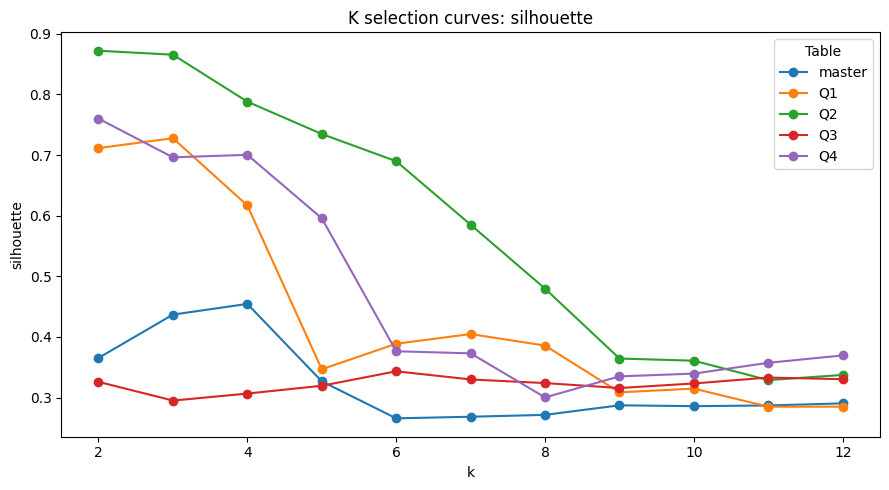

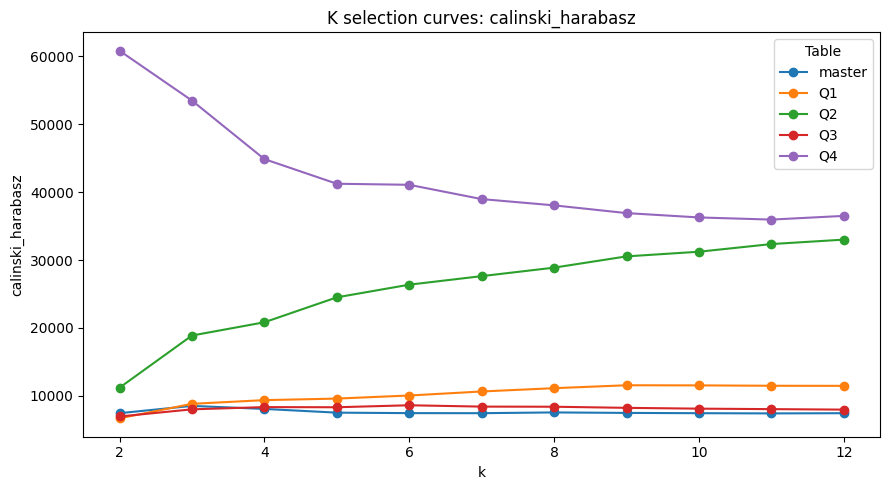

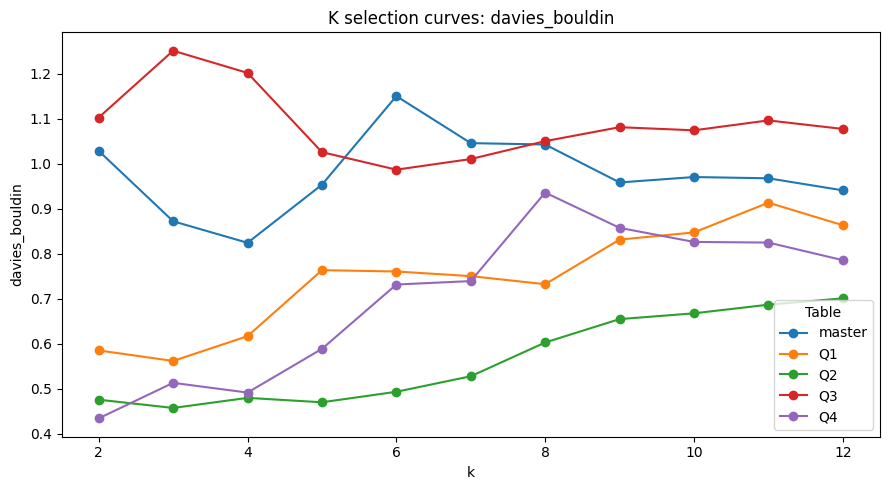

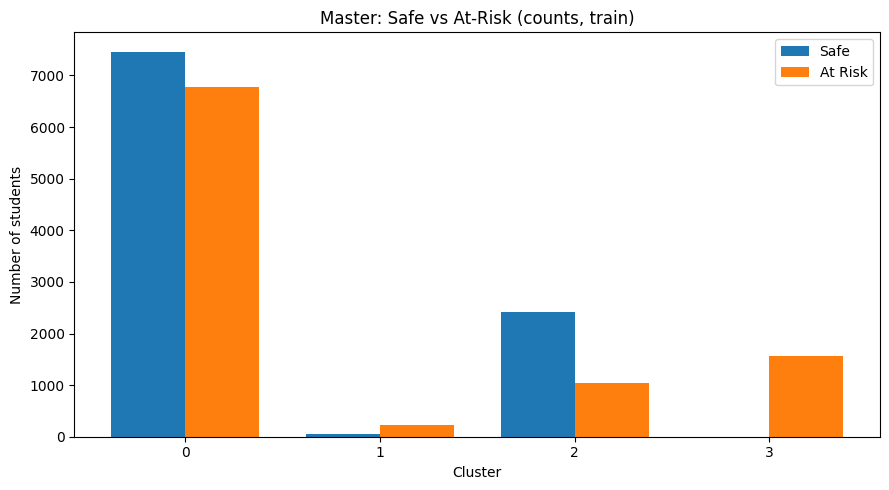

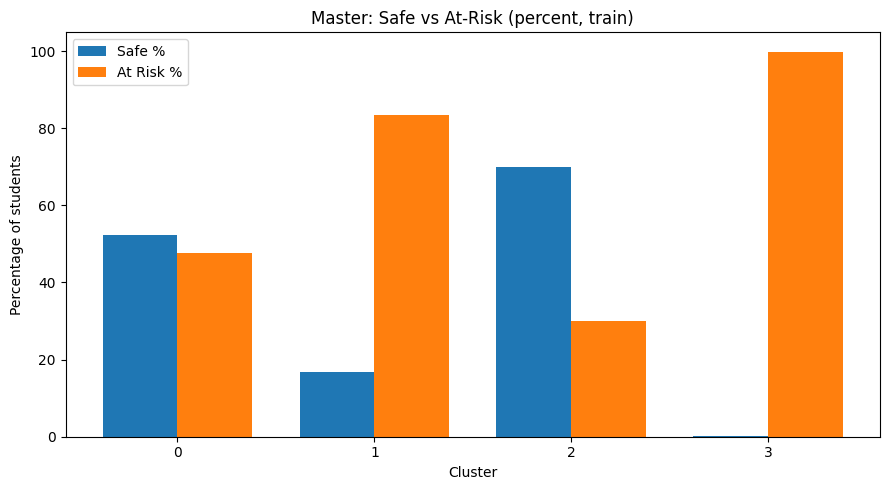

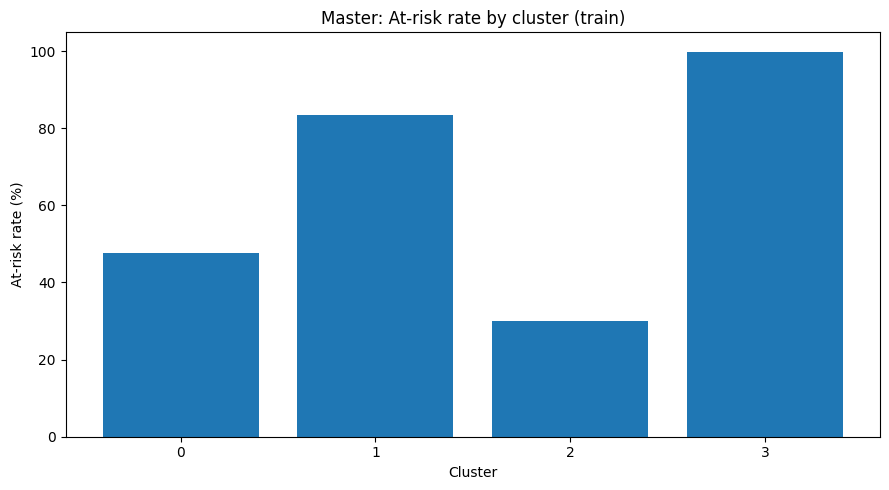

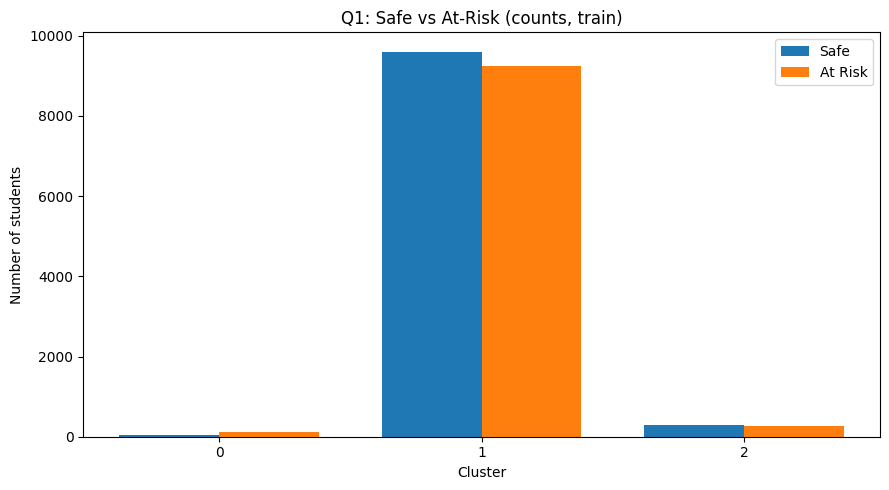

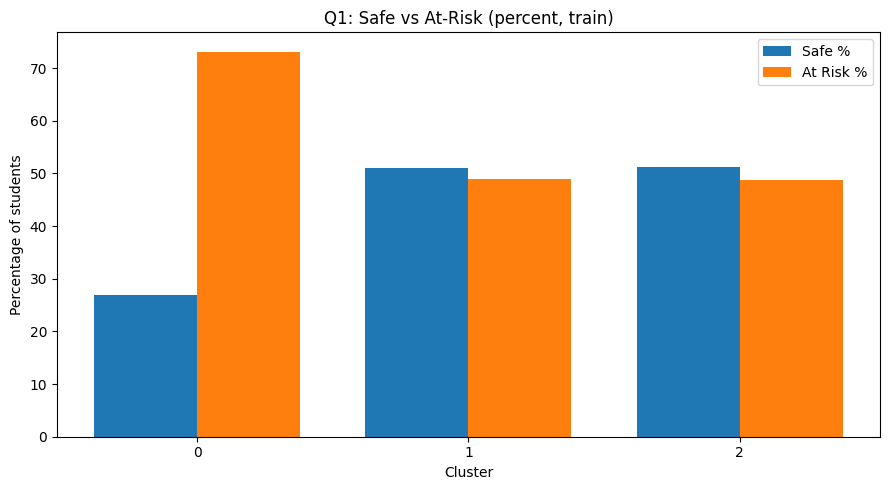

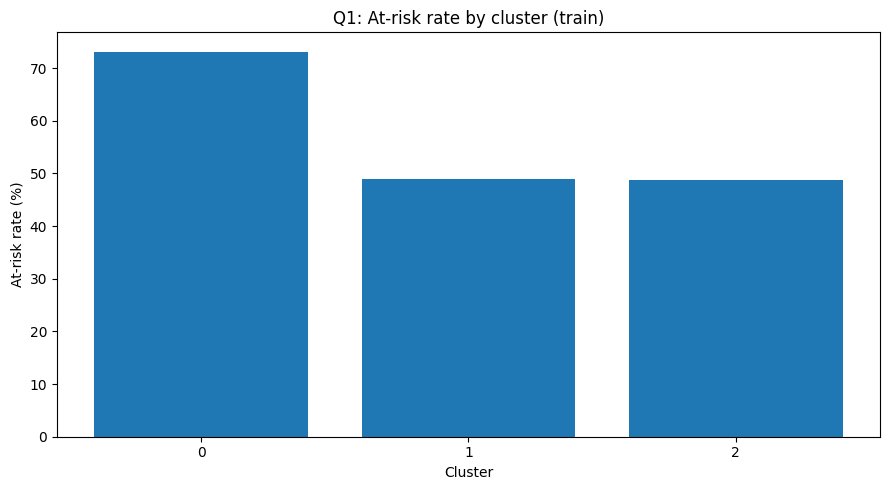

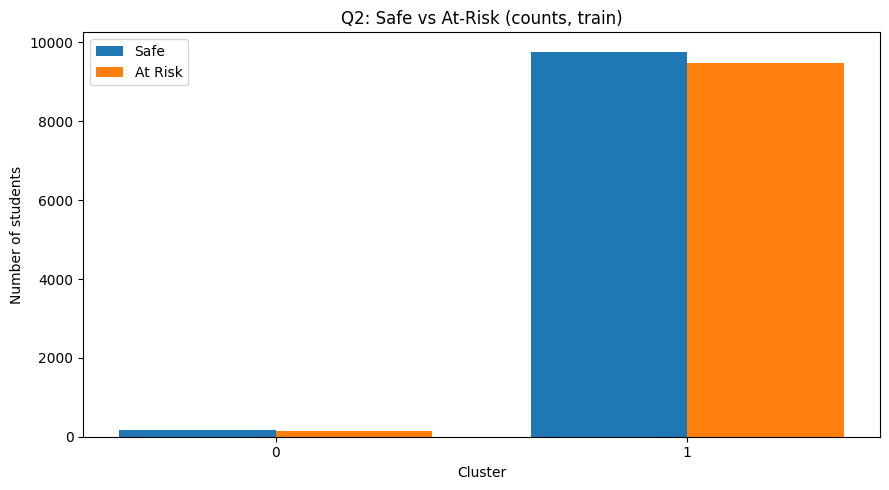

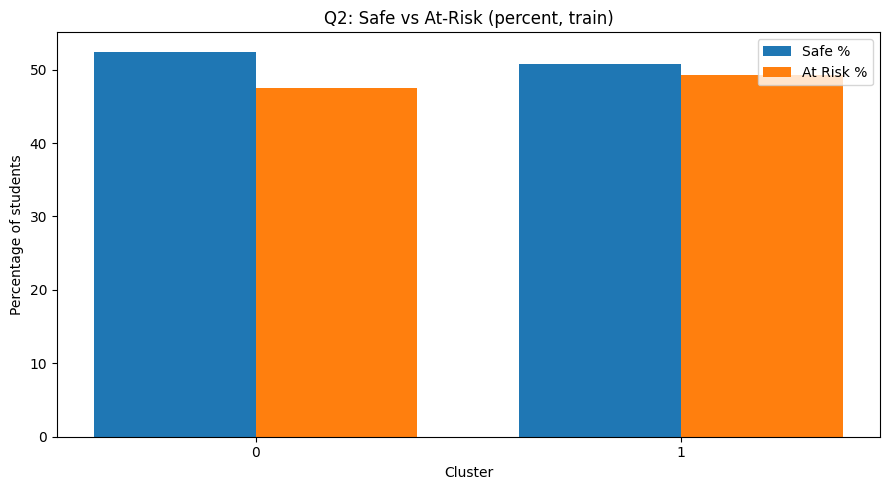

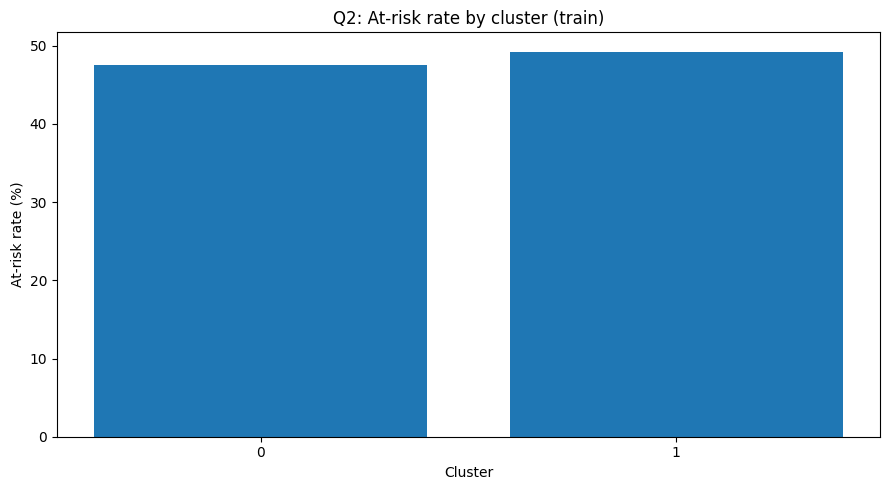

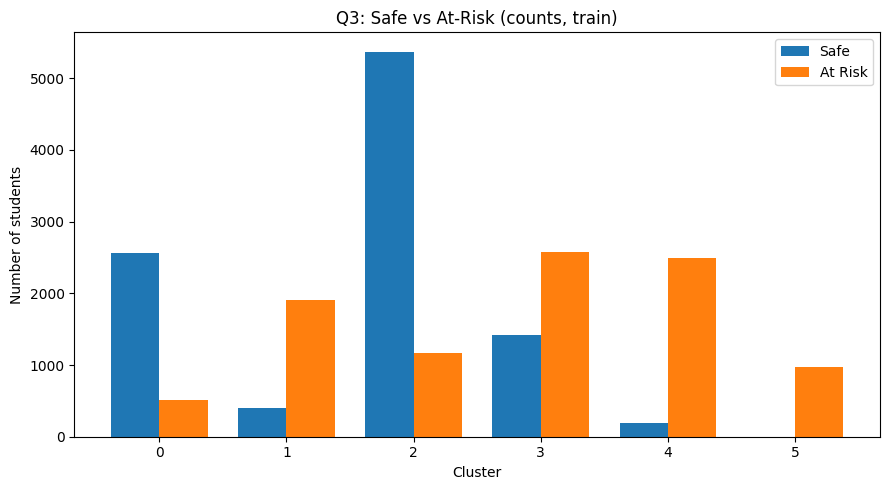

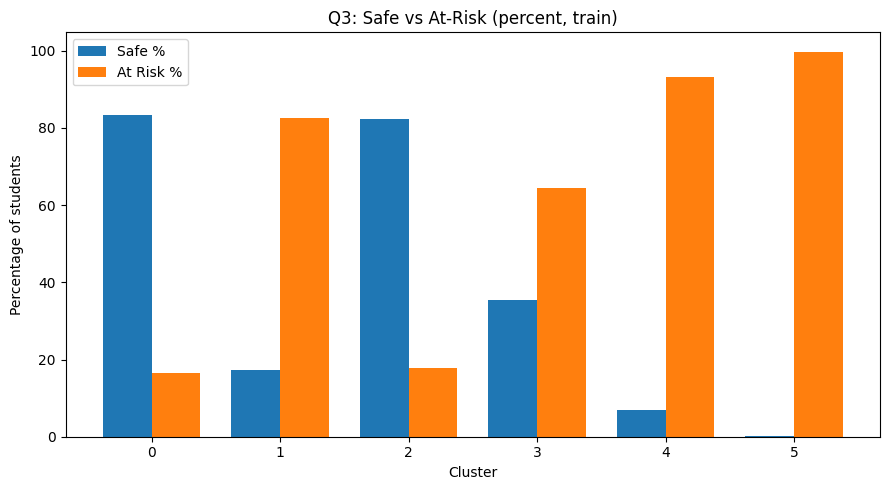

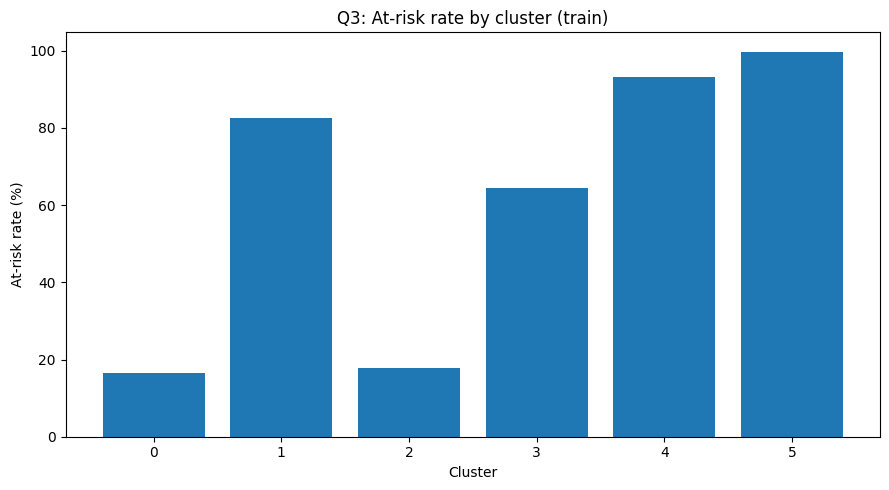

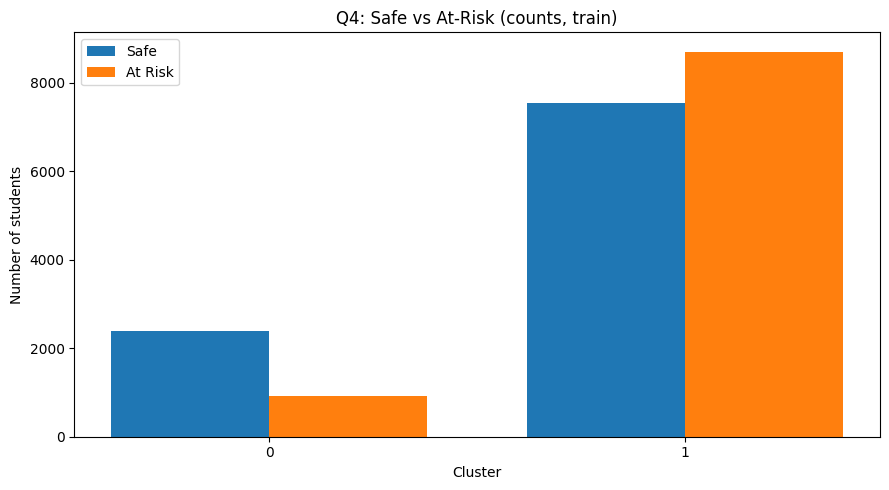

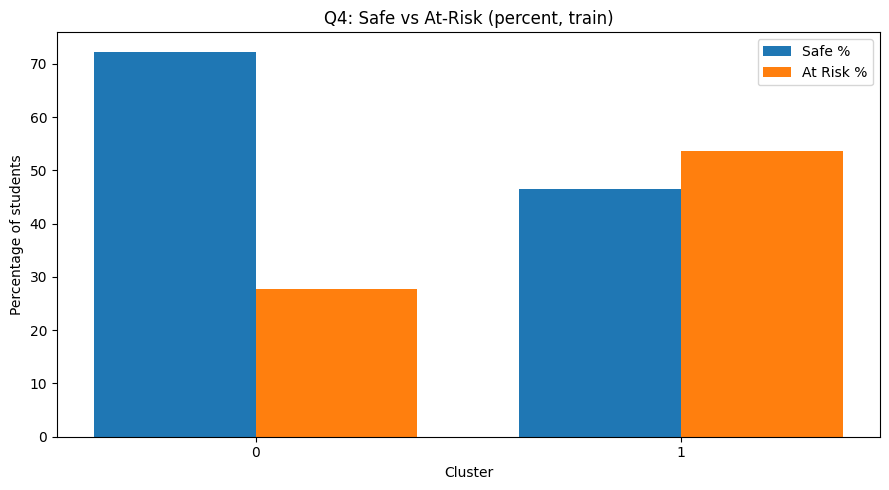

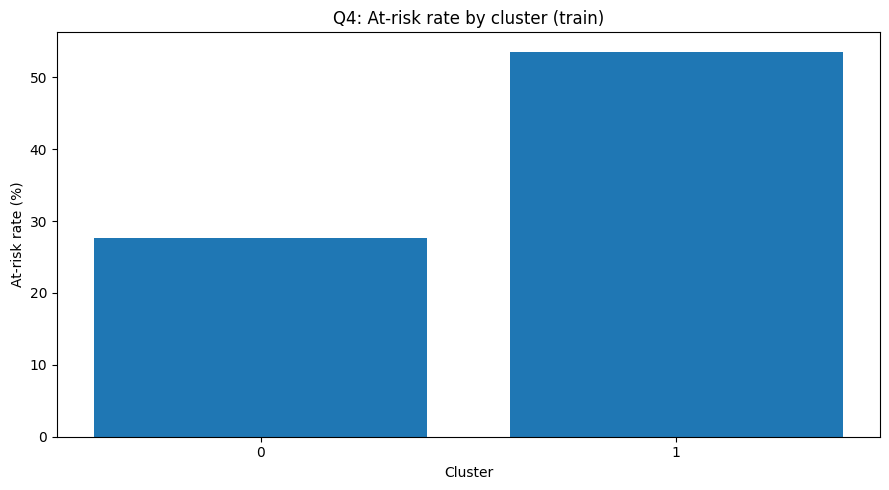

In [29]:
# -----------------------------
# Small utilities
# -----------------------------
def _safe_cols(df, cols):
    return [c for c in cols if c in df.columns]

def _cluster_metrics_from_models(cluster_models: dict):
    rows = []
    for name, bundle in cluster_models.items():
        m = bundle.get("metrics", None)
        if m is None or len(m) == 0:
            continue
        m = m.copy()
        m["table"] = name
        rows.append(m)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    return out[["table","k","silhouette","calinski_harabasz","davies_bouldin"]]

# -----------------------------
# 1) K selection curves
# -----------------------------
def plot_k_selection_curves(cluster_models, tables=("master","Q1","Q2","Q3","Q4")):
    metrics_df = _cluster_metrics_from_models(cluster_models)
    if metrics_df.empty:
        print("No metrics found in cluster_models (bundle['metrics'] missing).")
        return

    for metric in ["silhouette", "calinski_harabasz", "davies_bouldin"]:
        plt.figure(figsize=(9,5))
        for t in tables:
            d = metrics_df[metrics_df["table"] == t].sort_values("k")
            if d.empty:
                continue
            plt.plot(d["k"], d[metric], marker="o", label=str(t))
        plt.title(f"K selection curves: {metric}")
        plt.xlabel("k")
        plt.ylabel(metric)
        plt.legend(title="Table")
        plt.tight_layout()
        plt.show()

# -----------------------------
# 2) Cluster profile heatmap (means)
# -----------------------------
def cluster_profiles_table(df, cluster_col, feature_cols, outcome_col="target_at_risk"):
    feats = _safe_cols(df, feature_cols)
    base_cols = [cluster_col] + feats + ([outcome_col] if outcome_col in df.columns else [])
    base = df[base_cols].copy()

    for c in feats:
        base[c] = pd.to_numeric(base[c], errors="coerce").fillna(0.0)

    prof = base.groupby(cluster_col)[feats].mean()
    n = base.groupby(cluster_col).size().rename("n_students")
    out = prof.merge(n, left_index=True, right_index=True)

    if outcome_col in base.columns:
        at_risk = base.groupby(cluster_col)[outcome_col].mean().rename("at_risk_%") * 100.0
        out = out.merge(at_risk, left_index=True, right_index=True)

    return out.sort_index()



def plot_cluster_heatmap_with_values(df, cluster_col, feature_cols, title):
    
    profile = (
        df.groupby(cluster_col)[feature_cols]
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(10,5))
    sns.heatmap(
        profile,
        annot=True,          # <-- THIS shows the numbers
        fmt=".2f",           # <-- rounds to 2 decimals (0.78)
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title(title)
    plt.xlabel("Features")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3) Safe vs At-Risk bars (side-by-side)
# -----------------------------
def plot_safe_risk_side_by_side(df, cluster_col, title, outcome_col="target_at_risk"):
    dist = (
        df.groupby([cluster_col, outcome_col])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    if 0 not in dist.columns: dist[0] = 0
    if 1 not in dist.columns: dist[1] = 0
    dist = dist[[0,1]]
    dist.columns = ["Safe", "At_Risk"]

    clusters = dist.index.astype(str).tolist()
    x = np.arange(len(clusters))
    w = 0.38

    plt.figure(figsize=(9,5))
    plt.bar(x - w/2, dist["Safe"].to_numpy(), w, label="Safe")
    plt.bar(x + w/2, dist["At_Risk"].to_numpy(), w, label="At Risk")
    plt.xticks(x, clusters)
    plt.xlabel("Cluster")
    plt.ylabel("Number of students")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_safe_risk_side_by_side_pct(df, cluster_col, title, outcome_col="target_at_risk"):
    dist = (
        df.groupby([cluster_col, outcome_col])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    if 0 not in dist.columns: dist[0] = 0
    if 1 not in dist.columns: dist[1] = 0
    dist = dist[[0,1]]
    dist = dist.div(dist.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0) * 100.0
    dist.columns = ["Safe_%", "At_Risk_%"]

    clusters = dist.index.astype(str).tolist()
    x = np.arange(len(clusters))
    w = 0.38

    plt.figure(figsize=(9,5))
    plt.bar(x - w/2, dist["Safe_%"].to_numpy(), w, label="Safe %")
    plt.bar(x + w/2, dist["At_Risk_%"].to_numpy(), w, label="At Risk %")
    plt.xticks(x, clusters)
    plt.xlabel("Cluster")
    plt.ylabel("Percentage of students")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4) At-risk rate bar chart
# -----------------------------
def plot_risk_rate_by_cluster(df, cluster_col, title, outcome_col="target_at_risk"):
    rate = df.groupby(cluster_col)[outcome_col].mean().sort_index() * 100.0
    clusters = rate.index.astype(str).tolist()
    x = np.arange(len(clusters))

    plt.figure(figsize=(9,5))
    plt.bar(x, rate.to_numpy())
    plt.xticks(x, clusters)
    plt.xlabel("Cluster")
    plt.ylabel("At-risk rate (%)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 5) One function: run EVERYTHING (Master + Q1–Q4)
# -----------------------------
def visualize_all(ml_master_train, ml_Q1_train, ml_Q2_train, ml_Q3_train, ml_Q4_train,
                  CLUSTERING_FEATURES, CLUSTER_FEATURES_Q,
                  cluster_models=None):

    # K selection curves (optional)
    if cluster_models is not None:
        plot_k_selection_curves(cluster_models, tables=("master","Q1","Q2","Q3","Q4"))

    # # Master
    # plot_cluster_profile_heatmap(
    #     ml_master_train, "cluster_master_id", CLUSTERING_FEATURES,
    #     "Master: cluster feature means (train)"
    # )
    plot_safe_risk_side_by_side(
        ml_master_train, "cluster_master_id",
        "Master: Safe vs At-Risk (counts, train)"
    )
    plot_safe_risk_side_by_side_pct(
        ml_master_train, "cluster_master_id",
        "Master: Safe vs At-Risk (percent, train)"
    )
    plot_risk_rate_by_cluster(
        ml_master_train, "cluster_master_id",
        "Master: At-risk rate by cluster (train)"
    )

    # Quarters
    quarter_map = {
        "Q1": (ml_Q1_train, "cluster_Q1_id"),
        "Q2": (ml_Q2_train, "cluster_Q2_id"),
        "Q3": (ml_Q3_train, "cluster_Q3_id"),
        "Q4": (ml_Q4_train, "cluster_Q4_id"),
    }
    for q, (df, ccol) in quarter_map.items():
        # plot_cluster_profile_heatmap(
        #     df, ccol, CLUSTER_FEATURES_Q[q],
        #     f"{q}: cluster feature means (train)"
        # )
        plot_safe_risk_side_by_side(
            df, ccol,
            f"{q}: Safe vs At-Risk (counts, train)"
        )
        plot_safe_risk_side_by_side_pct(
            df, ccol,
            f"{q}: Safe vs At-Risk (percent, train)"
        )
        plot_risk_rate_by_cluster(
            df, ccol,
            f"{q}: At-risk rate by cluster (train)"
        )


visualize_all(
    ml_master_train, ml_Q1_train, ml_Q2_train, ml_Q3_train, ml_Q4_train,
    CLUSTERING_FEATURES, CLUSTER_FEATURES_Q,
    cluster_models=cluster_models   # optional; remove if you don’t want k-curves
)

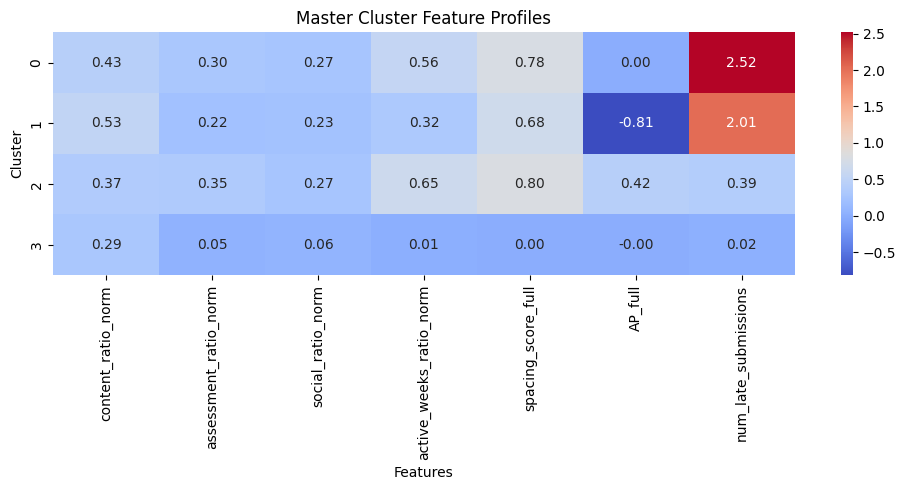

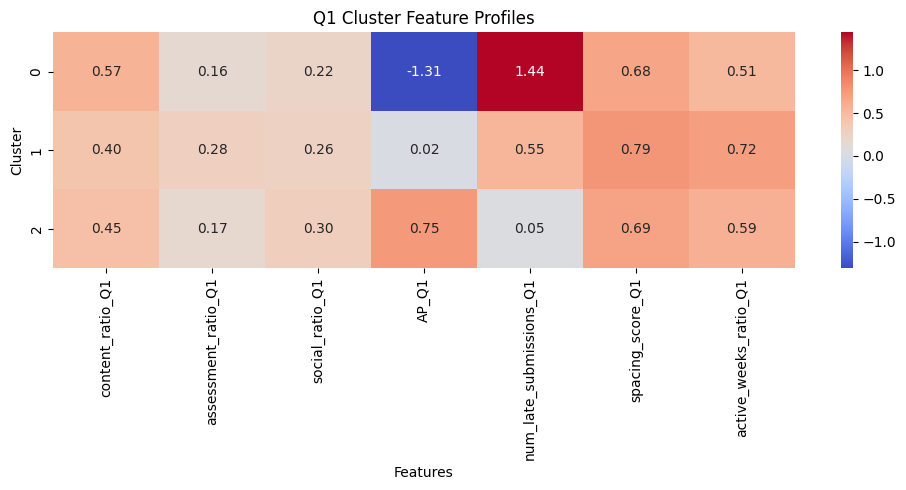

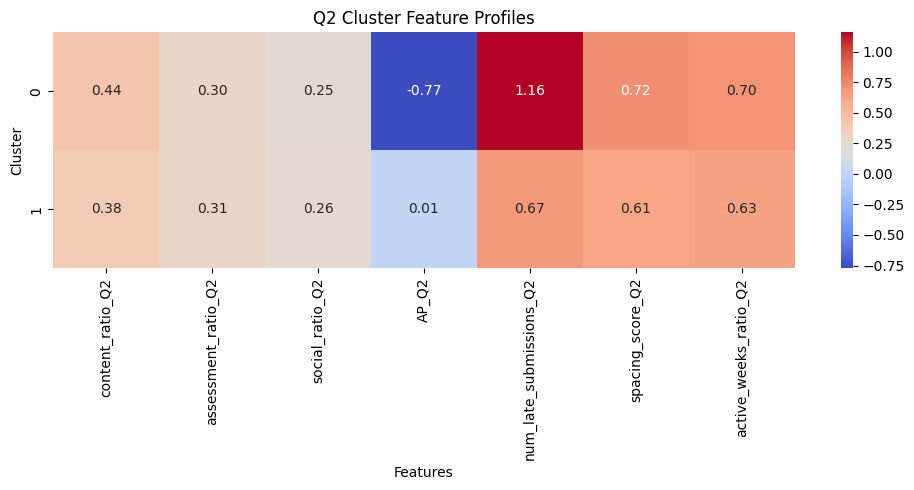

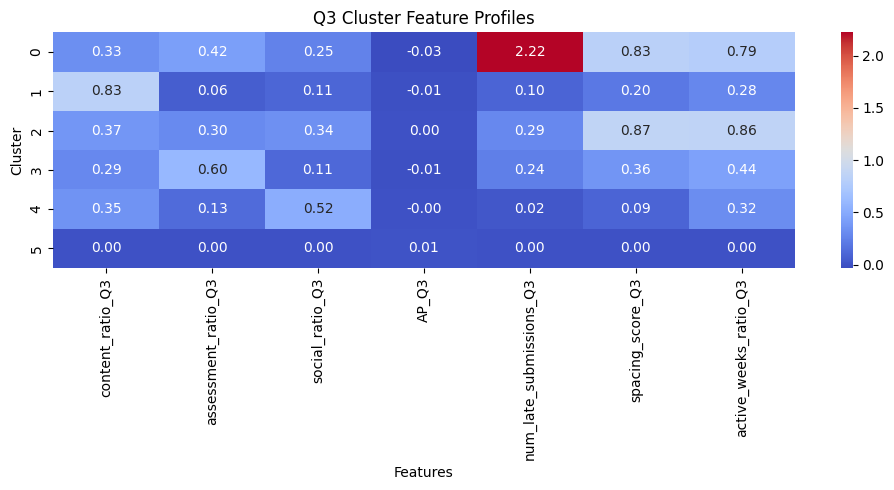

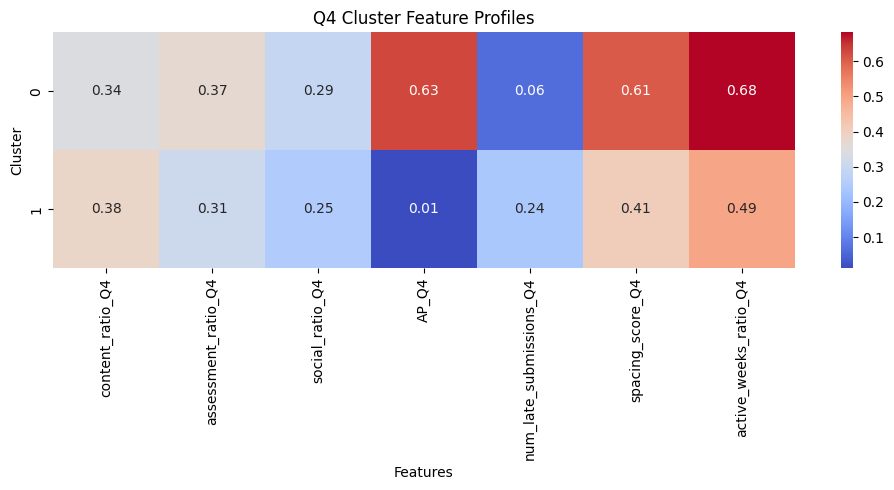

In [30]:
def plot_cluster_heatmap(df, cluster_col, feature_cols, title):
    profile = (
        df.groupby(cluster_col)[feature_cols]
        .mean()
    )

    plt.figure(figsize=(10,5))
    sns.heatmap(profile, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(title)
    plt.xlabel("Features")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

plot_cluster_heatmap(
    df=ml_master_train,
    cluster_col="cluster_master_id",
    feature_cols=CLUSTERING_FEATURES,
    title="Master Cluster Feature Profiles"
)

plot_cluster_heatmap(
    ml_Q1_train,
    cluster_col="cluster_Q1_id",
    feature_cols=CLUSTER_FEATURES_Q["Q1"],
    title="Q1 Cluster Feature Profiles"
)

plot_cluster_heatmap(
    ml_Q2_train,
    cluster_col="cluster_Q2_id",
    feature_cols=CLUSTER_FEATURES_Q["Q2"],
    title="Q2 Cluster Feature Profiles"
)

plot_cluster_heatmap(
    ml_Q3_train,
    cluster_col="cluster_Q3_id",
    feature_cols=CLUSTER_FEATURES_Q["Q3"],
    title="Q3 Cluster Feature Profiles"
)

plot_cluster_heatmap(
    ml_Q4_train,
    cluster_col="cluster_Q4_id",
    feature_cols=CLUSTER_FEATURES_Q["Q4"],
    title="Q4 Cluster Feature Profiles"
)

### Recommendation 

In [31]:

# =============================================================================
# ▶ BLOCK A  |  REPLACES Code Block 31
# =============================================================================

import numpy as np
import pandas as pd
from scipy.stats import pointbiserialr, f_oneway

# -----------------------------------------------------------------------------
# A1 — Intervention catalogue
#      Each entry: title, detail template, category, tier, vle_types
#      detail uses .format(student_val, peer_val, student_pct, peer_pct)
# -----------------------------------------------------------------------------

INTERVENTION_CATALOGUE = {

    # ── Assessment behaviour ──────────────────────────────────────────────────
    "AP_full": {
        "title":     "Submit Assessments Earlier",
        "detail":    (
            "Your submission timing score is {student_val:.2f} vs {peer_val:.2f} for "
            "passing students in your cluster. Submitting earlier gives you time to "
            "review feedback before the next task."
        ),
        "category":  "assessment",
        "tier":      1,
        "vle_types": ["quiz", "externalquiz", "questionnaire"],
    },
    "num_late_submissions": {
        "title":     "Reduce Late Submissions",
        "detail":    (
            "You have {student_val:.0f} late submission(s); successful peers average "
            "{peer_val:.1f}. Submitting even one day early reduces stress and "
            "protects your grade."
        ),
        "category":  "assessment",
        "tier":      1,
        "vle_types": ["quiz", "externalquiz", "questionnaire"],
    },
    "assessment_ratio_norm": {
        "title":     "Practise More Assessment Activities",
        "detail":    (
            "Assessment activities make up {student_pct:.0f}% of your engagement "
            "vs {peer_pct:.0f}% for peers who passed. Regular quiz and self-test "
            "practice strengthens recall and identifies gaps early."
        ),
        "category":  "assessment",
        "tier":      1,
        "vle_types": ["quiz", "externalquiz", "questionnaire"],
    },

    # ── Content engagement ────────────────────────────────────────────────────
    "content_ratio_norm": {
        "title":     "Engage More With Course Content",
        "detail":    (
            "Only {student_pct:.0f}% of your activity is on course materials vs "
            "{peer_pct:.0f}% for passing students. Prioritise readings and core "
            "resources before attempting assessments."
        ),
        "category":  "content",
        "tier":      1,
        "vle_types": ["oucontent", "resource", "url", "page", "subpage",
                      "homepage", "folder", "glossary", "htmlactivity"],
    },

    # ── Consistency / self-regulation ─────────────────────────────────────────
    "active_weeks_ratio_norm": {
        "title":     "Study More Consistently",
        "detail":    (
            "You were active in {student_pct:.0f}% of course weeks. Passing students "
            "in your group averaged {peer_pct:.0f}%. Logging in regularly — even for "
            "short sessions — outperforms occasional long ones."
        ),
        "category":  "consistency",
        "tier":      1,
        "vle_types": [],
    },
    "spacing_score_full": {
        "title":     "Spread Your Study Sessions",
        "detail":    (
            "Your spacing score is {student_val:.2f} vs {peer_val:.2f} for successful "
            "peers. Clustering all activity into a few days reduces retention. Aim for "
            "shorter, evenly distributed sessions each week."
        ),
        "category":  "consistency",
        "tier":      1,
        "vle_types": [],
    },

    # ── Social engagement ─────────────────────────────────────────────────────
    "social_ratio_norm": {
        "title":     "Participate in Discussions",
        "detail":    (
            "Forum and collaborative tool usage is {student_pct:.0f}% of your activity "
            "vs {peer_pct:.0f}% for peers who passed. Posting a question or reply "
            "once a week consistently improves learning outcomes."
        ),
        "category":  "social",
        "tier":      1,
        "vle_types": ["forumng", "ouwiki", "oucollaborate", "ouelluminate",
                      "dataplus", "sharedsubpage"],
    },
}

# ── Quarter variants — generated programmatically ────────────────────────────
_Q_TEMPLATES = {
    "AP": {
        "title_tpl":  "Submit Earlier ({q})",
        "detail_tpl": (
            "Your submission timing this quarter ({student_val:.2f}) is below "
            "the peer average ({peer_val:.2f}). Earlier submissions give you time "
            "to act on feedback before the next quarter."
        ),
        "category":  "assessment",
        "vle_types": ["quiz", "externalquiz", "questionnaire"],
    },
    "num_late_submissions": {
        "title_tpl":  "Reduce Late Submissions ({q})",
        "detail_tpl": (
            "You have {student_val:.0f} late submission(s) this quarter; peers "
            "who passed averaged {peer_val:.1f}."
        ),
        "category":  "assessment",
        "vle_types": ["quiz", "externalquiz", "questionnaire"],
    },
    "active_weeks_ratio": {
        "title_tpl":  "Study More Consistently ({q})",
        "detail_tpl": (
            "You were active in {student_pct:.0f}% of weeks this quarter. "
            "Passing students averaged {peer_pct:.0f}%. Short regular sessions "
            "beat occasional long ones."
        ),
        "category":  "consistency",
        "vle_types": [],
    },
    "spacing_score": {
        "title_tpl":  "Spread Your Sessions ({q})",
        "detail_tpl": (
            "Your spacing score this quarter is {student_val:.2f} vs "
            "{peer_val:.2f}. Distribute study time more evenly across the weeks."
        ),
        "category":  "consistency",
        "vle_types": [],
    },
    "content_ratio": {
        "title_tpl":  "Engage With Course Content ({q})",
        "detail_tpl": (
            "{student_pct:.0f}% of your activity this quarter is on course "
            "content vs {peer_pct:.0f}% for passing students."
        ),
        "category":  "content",
        "vle_types": ["oucontent", "resource", "url", "page", "subpage",
                      "homepage", "folder", "glossary", "htmlactivity"],
    },
    "assessment_ratio": {
        "title_tpl":  "Practise Assessments ({q})",
        "detail_tpl": (
            "Assessment activity is {student_pct:.0f}% of your engagement this "
            "quarter vs {peer_pct:.0f}% for peers who passed."
        ),
        "category":  "assessment",
        "vle_types": ["quiz", "externalquiz", "questionnaire"],
    },
    "social_ratio": {
        "title_tpl":  "Join the Discussion ({q})",
        "detail_tpl": (
            "Forum and collaborative usage is {student_pct:.0f}% of your activity "
            "this quarter vs {peer_pct:.0f}% for peers who passed."
        ),
        "category":  "social",
        "vle_types": ["forumng", "ouwiki", "oucollaborate"],
    },
}

for _base, _cfg in _Q_TEMPLATES.items():
    for _q in ["Q1", "Q2", "Q3", "Q4"]:
        INTERVENTION_CATALOGUE[f"{_base}_{_q}"] = {
            "title":     _cfg["title_tpl"].format(q=_q),
            "detail":    _cfg["detail_tpl"],
            "category":  _cfg["category"],
            "tier":      1,
            "vle_types": _cfg["vle_types"],
        }

_GENERIC_ENTRY = {
    "title":     "Improve {feature}",
    "detail":    (
        "Your value ({student_val:.2f}) is below the peer benchmark ({peer_val:.2f}). "
        "Closing this gap is associated with better outcomes in your learning group."
    ),
    "category":  "general",
    "tier":      1,
    "vle_types": [],
}

# -----------------------------------------------------------------------------
# A2 — Feature direction sets
# -----------------------------------------------------------------------------

HIGHER_IS_BETTER = {
    "active_weeks_ratio_norm", "spacing_score_full", "AP_full",
    "content_ratio_norm", "assessment_ratio_norm", "social_ratio_norm",
    *{f"active_weeks_ratio_{q}" for q in ["Q1","Q2","Q3","Q4"]},
    *{f"spacing_score_{q}"      for q in ["Q1","Q2","Q3","Q4"]},
    *{f"AP_{q}"                 for q in ["Q1","Q2","Q3","Q4"]},
    *{f"content_ratio_{q}"      for q in ["Q1","Q2","Q3","Q4"]},
    *{f"social_ratio_{q}"       for q in ["Q1","Q2","Q3","Q4"]},
    *{f"assessment_ratio_{q}"   for q in ["Q1","Q2","Q3","Q4"]},
}

LOWER_IS_BETTER = {
    "num_late_submissions",
    *{f"num_late_submissions_{q}" for q in ["Q1","Q2","Q3","Q4"]},
}

# -----------------------------------------------------------------------------
# A3 — VLE category ↔ activity_type mapping (for hybrid resource layer)
# -----------------------------------------------------------------------------

CATEGORY_TO_VLE = {
    "assessment":  {"quiz", "externalquiz", "questionnaire"},
    "content":     {"oucontent", "resource", "url", "page", "subpage",
                    "homepage", "folder", "glossary", "htmlactivity"},
    "social":      {"forumng", "ouwiki", "oucollaborate", "ouelluminate",
                    "dataplus", "sharedsubpage"},
    "consistency": set(),   # behavioural — no specific resource type
}

VLE_DISPLAY_NAMES = {
    "quiz":          "Practice Quiz",
    "externalquiz":  "External Quiz",
    "questionnaire": "Questionnaire",
    "oucontent":     "Course Content",
    "resource":      "Resource Document",
    "url":           "External Link",
    "page":          "Course Page",
    "subpage":       "Sub-page",
    "forumng":       "Discussion Forum",
    "ouwiki":        "Collaborative Wiki",
    "oucollaborate": "Collaboration Tool",
    "htmlactivity":  "Interactive Activity",
    "folder":        "Resource Folder",
    "glossary":      "Glossary",
}

# -----------------------------------------------------------------------------
# A4 — Tier escalation
#
#  Tier 1: Automated nudge      — low/medium risk, 1–2 gaps
#  Tier 2: Semi-personalised    — confirmed risk OR 3+ gaps in high-risk cluster
#  Tier 3: Human escalation     — confirmed risk + late quarter + many/severe gaps
# -----------------------------------------------------------------------------

def assign_intervention_tier(at_risk_flag, n_gaps, quarter, cluster_risk_rate):
    """
    Parameters
    ----------
    at_risk_flag      : int   — 1=at-risk, 0=safe, -1=unknown
    n_gaps            : int   — number of meaningful behavioural gaps
    quarter           : str   — "Q1"|"Q2"|"Q3"|"Q4"|"master"
    cluster_risk_rate : float — % at-risk in cluster (0–100)

    Returns (tier: int, label: str, rationale: str)
    """
    high_risk_cluster = cluster_risk_rate >= 50.0
    many_gaps         = n_gaps >= 3
    late_quarter      = quarter in ("Q3", "Q4", "master")
    confirmed_risk    = (at_risk_flag == 1)

    if confirmed_risk and late_quarter and (many_gaps or high_risk_cluster):
        return (
            3,
            "Human Escalation",
            "High risk with persistent gaps at a late course stage. "
            "Advisor outreach or one-to-one support recommended.",
        )
    if confirmed_risk or (many_gaps and high_risk_cluster):
        return (
            2,
            "Semi-Personalised Support",
            "Multiple behavioural gaps or elevated cluster risk. "
            "A targeted message from the support team is recommended.",
        )
    return (
        1,
        "Automated Nudge",
        "Early or single-behaviour gap. "
        "Automated reminder or study planning prompt is appropriate.",
    )


# -----------------------------------------------------------------------------
# A5 — Quarter context descriptors
# -----------------------------------------------------------------------------

QUARTER_CONTEXT = {
    "Q1": {
        "label":      "Quarter 1 — Early Course",
        "focus":      "Habit formation and initial engagement.",
        "guidance":   "High uncertainty — use low-cost nudges only.",
        "confidence": "low",
    },
    "Q2": {
        "label":      "Quarter 2 — Primary Checkpoint ★",
        "focus":      "Main intervention window.",
        "guidance":   "Best balance of evidence and time to act. Recommended deployment point.",
        "confidence": "medium",
    },
    "Q3": {
        "label":      "Quarter 3 — Refinement Checkpoint",
        "focus":      "Escalate if weak patterns from Q2 persist.",
        "guidance":   "Escalation is appropriate for unresolved gaps.",
        "confidence": "high",
    },
    "Q4": {
        "label":      "Quarter 4 — Late Course",
        "focus":      "Diagnostic and support continuation.",
        "guidance":   "Limited recovery time — escalate persistent cases.",
        "confidence": "high",
    },
    "master": {
        "label":      "Full Course View",
        "focus":      "Complete behavioural profile across all weeks.",
        "guidance":   "Use for retrospective analysis and full-course support.",
        "confidence": "high",
    },
}

In [32]:

# =============================================================================
# ▶ BLOCK B  |  REPLACES Code Block 32
# =============================================================================

def _compute_risk_correlation_weights(df, feature_cols, target_col="target_at_risk"):
    """
    Point-biserial |correlation| of each feature with the binary risk label.
    Answers: does this behaviour actually relate to academic risk?
    Returns {feature: normalised_weight}.
    """
    weights = {}
    y = df[target_col].values
    for feat in feature_cols:
        x = pd.to_numeric(df[feat], errors="coerce").fillna(0.0).values
        if x.std() < 1e-9:
            weights[feat] = 0.0
            continue
        corr, _        = pointbiserialr(y, x)
        weights[feat]  = abs(corr)
    total = sum(weights.values()) + 1e-9
    return {k: v / total for k, v in weights.items()}


def _compute_cluster_separability_weights(df, feature_cols, cluster_col):
    """
    ANOVA F-statistic of each feature across clusters.
    Answers: does this behaviour define how students are grouped?
    Returns {feature: normalised_weight}.
    """
    weights = {}
    for feat in feature_cols:
        groups = [grp[feat].dropna().values for _, grp in df.groupby(cluster_col)]
        groups = [g for g in groups if len(g) > 1]
        if len(groups) < 2:
            weights[feat] = 0.0
            continue
        f_stat, _      = f_oneway(*groups)
        weights[feat]  = max(float(f_stat), 0.0)
    total = sum(weights.values()) + 1e-9
    return {k: v / total for k, v in weights.items()}


def _apply_redundancy_penalty(weights, df, feature_cols, threshold=0.75):
    """
    Damp the weight of any feature that is highly correlated with a
    higher-weighted feature. Prevents near-identical behaviours from
    producing duplicate recommendations at the top of the list.
    Applied AFTER compositing, not before.
    """
    available   = [f for f in feature_cols if f in df.columns]
    corr_matrix = df[available].corr().abs()
    penalised   = weights.copy()
    seen        = set()

    for feat, _ in sorted(weights.items(), key=lambda x: x[1], reverse=True):
        if feat in seen:
            continue
        seen.add(feat)
        for other in available:
            if other == feat or other in seen:
                continue
            if corr_matrix.loc[feat, other] > threshold:
                penalised[other] *= (1.0 - corr_matrix.loc[feat, other])
                seen.add(other)

    total = sum(penalised.values()) + 1e-9
    return {k: v / total for k, v in penalised.items()}


def compute_feature_weights(
    df,
    feature_cols,
    cluster_col,
    target_col           = "target_at_risk",
    alpha                = 0.50,   # risk correlation    → relevance
    beta                 = 0.30,   # cluster separability → structural signal
    gamma                = 0.20,   # uniform baseline     → interpretability floor
    redundancy_threshold = 0.75,
):
    """
    Composite feature importance weights.  No supervised model required.

    Formula
    -------
    w_raw = alpha  * |corr(feature, risk_label)|
          + beta   * norm(ANOVA_F(feature | cluster))
          + gamma  * 1/n_features          ← prevents any weight reaching zero

    Redundancy penalty is applied AFTER normalisation.

    Returns
    -------
    weights   : dict {feature: float}  (sum ≈ 1)
    weight_df : pd.DataFrame  — full breakdown for inspection / reporting
    """
    feature_cols = [f for f in feature_cols if f in df.columns]
    n = len(feature_cols)
    if n == 0:
        return {}, pd.DataFrame()

    w_risk    = _compute_risk_correlation_weights(df, feature_cols, target_col)
    w_cluster = _compute_cluster_separability_weights(df, feature_cols, cluster_col)
    w_uniform = {f: 1.0 / n for f in feature_cols}

    composite = {
        f: (
              alpha  * w_risk.get(f, 0.0)
            + beta   * w_cluster.get(f, 0.0)
            + gamma  * w_uniform.get(f, 0.0)
        )
        for f in feature_cols
    }
    total     = sum(composite.values()) + 1e-9
    composite = {k: v / total for k, v in composite.items()}
    composite = _apply_redundancy_penalty(composite, df, feature_cols, redundancy_threshold)

    weight_df = pd.DataFrame({
        "feature":              feature_cols,
        "risk_correlation":     [round(w_risk.get(f, 0.0), 4)    for f in feature_cols],
        "cluster_separability": [round(w_cluster.get(f, 0.0), 4) for f in feature_cols],
        "composite_weight":     [round(composite.get(f, 0.0), 4) for f in feature_cols],
    }).sort_values("composite_weight", ascending=False).reset_index(drop=True)

    return composite, weight_df


In [33]:

# =============================================================================
# ▶ BLOCK C  |  REPLACES Code Block 33
# =============================================================================

# -----------------------------------------------------------------------------
# C1 — Template renderer
# -----------------------------------------------------------------------------

def _render_intervention(feature, student_val, peer_val):
    """
    Inject values into the catalogue entry for a given feature.
    Returns (title, detail, category, vle_types).
    Falls back to _GENERIC_ENTRY for unknown features.
    """
    entry = INTERVENTION_CATALOGUE.get(feature)
    if entry is None:
        entry = {
            **_GENERIC_ENTRY,
            "title": _GENERIC_ENTRY["title"].format(feature=feature),
        }
    fmt = dict(
        student_val = student_val,
        peer_val    = peer_val,
        student_pct = student_val * 100,
        peer_pct    = peer_val    * 100,
        feature     = feature,
    )
    try:
        title  = entry["title"].format(**fmt)
        detail = entry["detail"].format(**fmt)
    except (KeyError, ValueError):
        title  = entry.get("title", feature)
        detail = f"Your value ({student_val:.2f}) vs peer average ({peer_val:.2f})."
    return title, detail, entry.get("category", "general"), entry.get("vle_types", [])


# -----------------------------------------------------------------------------
# C2 — Hybrid resource recommendation layer
#
#  Content-based:   match VLE resource types to the student's weak categories
#  Collaborative:   count how many distinct resources of that type are available
#                   (proxy for what successful peers can and do engage with)
#  Hybrid score:    content_relevance × resource_availability
# -----------------------------------------------------------------------------

def build_hybrid_resource_recommendations(
    weak_categories,
    cluster_id,
    ml_train_df,
    vle_df,
    cluster_col,
    top_n = 3,
):
    """
    Suggest VLE resource types based on behavioural weaknesses cross-referenced
    with successful peer behaviour in the same cluster.

    Parameters
    ----------
    weak_categories : list[str]    — e.g. ["assessment", "content"]
    cluster_id      : int
    ml_train_df     : pd.DataFrame — training set with cluster labels
    vle_df          : pd.DataFrame — raw vle table (id_site, activity_type)
    cluster_col     : str
    top_n           : int

    Returns
    -------
    list[dict]
    """
    if vle_df is None or len(vle_df) == 0 or not weak_categories:
        return []

    target_types = set()
    for cat in weak_categories:
        target_types |= CATEGORY_TO_VLE.get(cat, set())
    if not target_types:
        return []

    # Content-based: how many resources of each relevant type exist?
    vle_meta    = vle_df[["id_site", "activity_type"]].drop_duplicates()
    type_counts = (
        vle_meta[vle_meta["activity_type"].isin(target_types)]
        .groupby("activity_type")["id_site"]
        .nunique()
        .reset_index()
        .rename(columns={"id_site": "n_available"})
        .sort_values("n_available", ascending=False)
    )
    if type_counts.empty:
        return []

    # Collaborative: count of successful peers in this cluster (context label)
    n_peers = int(ml_train_df[
        (ml_train_df[cluster_col]      == cluster_id) &
        (ml_train_df["target_at_risk"] == 0)
    ].shape[0])

    recs = []
    for _, row in type_counts.head(top_n).iterrows():
        act_type   = row["activity_type"]
        n_avail    = int(row["n_available"])
        display    = VLE_DISPLAY_NAMES.get(act_type, act_type.title())
        source_cat = next(
            (c for c, types in CATEGORY_TO_VLE.items() if act_type in types), "general"
        )
        recs.append({
            "activity_type": act_type,
            "display_name":  display,
            "category":      source_cat,
            "n_available":   n_avail,
            "rationale": (
                f"Successful students in your cluster ({n_peers} peers) engage with "
                f"{display} resources. {n_avail} item(s) of this type are available "
                f"in your course."
            ),
        })
    return recs


# -----------------------------------------------------------------------------
# C3 — Core recommendation generator
# -----------------------------------------------------------------------------

def generate_recommendations(
    student_row,
    ml_train_df,
    feature_cols,
    cluster_col,
    weights,
    quarter           = "master",
    top_n             = 5,
    min_gap_threshold = 0.01,
    vle_df            = None,
):
    """
    Generate ranked behavioural recommendations for one student.

    Pipeline
    --------
    1. Find the student's cluster
    2. Build successful-peer profile (same cluster, target_at_risk==0)
    3. Compute directional gap per feature
    4. Drop sub-threshold gaps (noise suppression)
    5. Multiply gap by feature weight → weighted_gap
    6. Rank descending, take top_n
    7. Assign intervention tier
    8. Generate hybrid resource suggestions

    Returns
    -------
    recommendations : list[dict]
    peer_profile    : dict
    cluster_meta    : dict  — includes peer_fallback_used flag
    resource_recs   : list[dict]
    tier_info       : dict
    """
    feature_cols = [
        f for f in feature_cols
        if f in ml_train_df.columns and f in student_row.index
    ]
    cluster_id   = int(student_row[cluster_col])
    at_risk_flag = int(student_row.get("target_at_risk", -1))

    # Steps 1–2: peer group
    cluster_mask    = ml_train_df[cluster_col] == cluster_id
    successful_mask = ml_train_df["target_at_risk"] == 0
    peers           = ml_train_df[cluster_mask & successful_mask]
    peer_fallback   = len(peers) < 5
    if peer_fallback:
        peers = ml_train_df[successful_mask]
    peer_means = peers[feature_cols].mean()

    # Steps 3–6: gap computation and ranking
    gaps = []
    for feat in feature_cols:
        student_val = float(student_row[feat])
        peer_val    = float(peer_means[feat])
        w           = weights.get(feat, 1.0 / max(len(feature_cols), 1))

        if feat in HIGHER_IS_BETTER:
            raw_gap = peer_val - student_val
        elif feat in LOWER_IS_BETTER:
            raw_gap = student_val - peer_val
        else:
            raw_gap = abs(peer_val - student_val)

        if raw_gap < min_gap_threshold:
            continue

        title, detail, category, _ = _render_intervention(feat, student_val, peer_val)
        gaps.append({
            "feature":      feat,
            "title":        title,
            "detail":       detail,
            "category":     category,
            "student_val":  round(student_val, 3),
            "peer_val":     round(peer_val, 3),
            "raw_gap":      round(raw_gap, 3),
            "weight":       round(w, 4),
            "weighted_gap": round(raw_gap * w, 4),
            "priority":     0,
        })

    gaps.sort(key=lambda x: x["weighted_gap"], reverse=True)
    top_gaps = gaps[:top_n]
    for rank, g in enumerate(top_gaps, start=1):
        g["priority"] = rank

    # Step 7: cluster metadata + tier
    cluster_all = ml_train_df[cluster_mask]
    risk_rate   = round(float(cluster_all["target_at_risk"].mean()) * 100, 1)

    cluster_meta = {
        "cluster_id":         cluster_id,
        "cluster_size":       len(cluster_all),
        "n_peers_used":       len(peers),
        "cluster_risk_rate":  risk_rate,
        "peer_fallback_used": peer_fallback,
    }

    tier, tier_label, tier_rationale = assign_intervention_tier(
        at_risk_flag      = at_risk_flag,
        n_gaps            = len(top_gaps),
        quarter           = quarter,
        cluster_risk_rate = risk_rate,
    )
    for g in top_gaps:
        g["tier"] = tier

    tier_info = {
        "tier":           tier,
        "tier_label":     tier_label,
        "tier_rationale": tier_rationale,
        "quarter_ctx":    QUARTER_CONTEXT.get(quarter, QUARTER_CONTEXT["master"]),
    }

    # Step 8: hybrid resource suggestions
    weak_categories = list({g["category"] for g in top_gaps})
    resource_recs   = build_hybrid_resource_recommendations(
        weak_categories = weak_categories,
        cluster_id      = cluster_id,
        ml_train_df     = ml_train_df,
        vle_df          = vle_df,
        cluster_col     = cluster_col,
        top_n           = 3,
    )

    peer_profile = {f: round(float(peer_means[f]), 3) for f in feature_cols}
    return top_gaps, peer_profile, cluster_meta, resource_recs, tier_info


# -----------------------------------------------------------------------------
# C4 — End-to-end report builder
# -----------------------------------------------------------------------------

def build_recommendation_report(
    student_id,
    code_module,
    code_presentation,
    ml_train_df,
    ml_live_df,
    feature_cols,
    cluster_col,
    weights,
    quarter = "master",
    top_n   = 5,
    vle_df  = None,
):
    """
    Look up one student and run the full recommendation pipeline.

    Parameters
    ----------
    ml_live_df : pd.DataFrame — cohort the student belongs to
    vle_df     : pd.DataFrame or None — raw vle table (enables hybrid layer)
    quarter    : str — controls tier logic and context messaging

    Returns
    -------
    report : dict — contains "error" key on lookup failure, otherwise full output
    """
    mask = (
        (ml_live_df["id_student"]        == student_id) &
        (ml_live_df["code_module"]        == code_module) &
        (ml_live_df["code_presentation"]  == code_presentation)
    )
    matches = ml_live_df[mask]
    if matches.empty:
        return {
            "error": (
                f"Student {student_id} not found in "
                f"{code_module} / {code_presentation}."
            )
        }

    student_row = matches.iloc[0]
    at_risk     = int(student_row.get("target_at_risk", -1))

    recs, peer_profile, cluster_meta, resource_recs, tier_info = generate_recommendations(
        student_row   = student_row,
        ml_train_df   = ml_train_df,
        feature_cols  = feature_cols,
        cluster_col   = cluster_col,
        weights       = weights,
        quarter       = quarter,
        top_n         = top_n,
        vle_df        = vle_df,
    )

    return {
        "student_id":        student_id,
        "code_module":       code_module,
        "code_presentation": code_presentation,
        "at_risk":           at_risk,
        "cluster_meta":      cluster_meta,
        "peer_profile":      peer_profile,
        "recommendations":   recs,
        "resource_recs":     resource_recs,
        "tier_info":         tier_info,
        "n_recs":            len(recs),
    }


# =============================================================================
# QUARTER → FEATURE/CLUSTER MAPPING  (shared by all wrappers)
# =============================================================================

QUARTER_MAP = {
    "master": {
        "train_attr":   "ml_master_train",
        "test_attr":    "ml_master_test",
        "feats_attr":   "CLUSTERING_FEATURES",
        "cluster_col":  "cluster_master_id",
    },
    "Q1": {"train_attr": "ml_Q1_train", "test_attr": "ml_Q1_test",
           "feats_attr": "Q1", "cluster_col": "cluster_Q1_id"},
    "Q2": {"train_attr": "ml_Q2_train", "test_attr": "ml_Q2_test",
           "feats_attr": "Q2", "cluster_col": "cluster_Q2_id"},
    "Q3": {"train_attr": "ml_Q3_train", "test_attr": "ml_Q3_test",
           "feats_attr": "Q3", "cluster_col": "cluster_Q3_id"},
    "Q4": {"train_attr": "ml_Q4_train", "test_attr": "ml_Q4_test",
           "feats_attr": "Q4", "cluster_col": "cluster_Q4_id"},
}


def _resolve_quarter_tables(quarter, ml_master_train, ml_master_test,
                            ml_Q1_train, ml_Q1_test,
                            ml_Q2_train, ml_Q2_test,
                            ml_Q3_train, ml_Q3_test,
                            ml_Q4_train, ml_Q4_test,
                            CLUSTERING_FEATURES, CLUSTER_FEATURES_Q):
    """
    Return (train_df, test_df, feature_cols, cluster_col) for a given quarter key.
    Centralises the mapping so every wrapper uses the same logic.
    """
    tables = {
        "master": (ml_master_train, ml_master_test, CLUSTERING_FEATURES, "cluster_master_id"),
        "Q1":     (ml_Q1_train,     ml_Q1_test,     CLUSTER_FEATURES_Q["Q1"], "cluster_Q1_id"),
        "Q2":     (ml_Q2_train,     ml_Q2_test,     CLUSTER_FEATURES_Q["Q2"], "cluster_Q2_id"),
        "Q3":     (ml_Q3_train,     ml_Q3_test,     CLUSTER_FEATURES_Q["Q3"], "cluster_Q3_id"),
        "Q4":     (ml_Q4_train,     ml_Q4_test,     CLUSTER_FEATURES_Q["Q4"], "cluster_Q4_id"),
    }
    if quarter not in tables:
        raise ValueError(f"quarter must be one of {list(tables.keys())}, got '{quarter}'")
    return tables[quarter]

In [34]:

# =============================================================================
# --- Code Block 34 ---
# =============================================================================
# TRANSLATION LAYER
# Single source of truth for all user-facing text.
# Maps internal feature names, tier codes, and quarter keys to plain English.
# The dashboard never reads raw feature names or cluster IDs.
# =============================================================================

import numpy as np
import pandas as pd

FEATURE_TO_ISSUE = {
    "AP_full": "Late assessment preparation",
    "AP_Q1": "Late assessment preparation",
    "AP_Q2": "Late assessment preparation",
    "AP_Q3": "Late assessment preparation",
    "AP_Q4": "Late assessment preparation",
    "num_late_submissions": "Frequent late submissions",
    "num_late_submissions_Q1": "Frequent late submissions",
    "num_late_submissions_Q2": "Frequent late submissions",
    "num_late_submissions_Q3": "Frequent late submissions",
    "num_late_submissions_Q4": "Frequent late submissions",
    "assessment_ratio_norm": "Low assessment practice",
    "assessment_ratio_Q1": "Low assessment practice",
    "assessment_ratio_Q2": "Low assessment practice",
    "assessment_ratio_Q3": "Low assessment practice",
    "assessment_ratio_Q4": "Low assessment practice",
    "content_ratio_norm": "Low engagement with course materials",
    "content_ratio_Q1": "Low engagement with course materials",
    "content_ratio_Q2": "Low engagement with course materials",
    "content_ratio_Q3": "Low engagement with course materials",
    "content_ratio_Q4": "Low engagement with course materials",
    "spacing_score_full": "Irregular study pattern",
    "spacing_score_Q1": "Irregular study pattern",
    "spacing_score_Q2": "Irregular study pattern",
    "spacing_score_Q3": "Irregular study pattern",
    "spacing_score_Q4": "Irregular study pattern",
    "active_weeks_ratio_norm": "Low study consistency",
    "active_weeks_ratio_Q1": "Low study consistency",
    "active_weeks_ratio_Q2": "Low study consistency",
    "active_weeks_ratio_Q3": "Low study consistency",
    "active_weeks_ratio_Q4": "Low study consistency",
    "social_ratio_norm": "Low participation in discussions",
    "social_ratio_Q1": "Low participation in discussions",
    "social_ratio_Q2": "Low participation in discussions",
    "social_ratio_Q3": "Low participation in discussions",
    "social_ratio_Q4": "Low participation in discussions",
}

ISSUE_TO_AREA = {
    "Late assessment preparation":          "Assessment behaviour",
    "Frequent late submissions":            "Assessment behaviour",
    "Low assessment practice":              "Assessment behaviour",
    "Low engagement with course materials": "Use of course materials",
    "Irregular study pattern":              "Study regularity",
    "Low study consistency":                "Study consistency",
    "Low participation in discussions":     "Participation",
}

ISSUE_TO_REC_CARD = {
    "Late assessment preparation": {
        "title":          "Submit assessments earlier",
        "explanation":    (
            "Your assessments are being submitted close to or after the deadline. "
            "Students who submit earlier tend to perform better overall."
        ),
        "why_it_matters": (
            "Submitting early gives you time to review feedback and act on it "
            "before your next assessment."
        ),
        "action": (
            "Set a personal deadline 2-3 days before the official one. "
            "Start your work as soon as it is released."
        ),
    },
    "Frequent late submissions": {
        "title":          "Reduce late submissions",
        "explanation":    (
            "You have submitted work after the deadline more than once. "
            "Late submissions put pressure on your grades and your learning."
        ),
        "why_it_matters": (
            "Submitting on time is one of the strongest habits among students "
            "who pass this course."
        ),
        "action": (
            "Use a weekly planner to map out all deadlines at the start of each "
            "month. Aim to finish each piece of work one day early."
        ),
    },
    "Low assessment practice": {
        "title":          "Practise more with quizzes and self-tests",
        "explanation":    (
            "You are spending a smaller share of your study time on practice "
            "assessments compared with students who are doing well."
        ),
        "why_it_matters": (
            "Regular self-testing strengthens memory and helps you spot gaps "
            "in your understanding early enough to fix them."
        ),
        "action": (
            "Spend at least 20 minutes each week on the available quizzes, "
            "even when they are not graded."
        ),
    },
    "Low engagement with course materials": {
        "title":          "Engage more with course content",
        "explanation":    (
            "You are using course reading materials, videos, and resources "
            "less than most students who pass this course."
        ),
        "why_it_matters": (
            "Reading and engaging with core materials before assessments "
            "builds the foundation needed to answer questions well."
        ),
        "action": (
            "Before each assessed activity, revisit the relevant course pages "
            "and work through any provided resources."
        ),
    },
    "Irregular study pattern": {
        "title":          "Spread your study across the week",
        "explanation":    (
            "Your study activity is concentrated into a few bursts rather than "
            "being spread consistently across the course."
        ),
        "why_it_matters": (
            "Short, regular sessions improve long-term retention far more than "
            "last-minute cramming."
        ),
        "action": (
            "Aim for sessions of 30-60 minutes on most days of the week, "
            "rather than one long session only before deadlines."
        ),
    },
    "Low study consistency": {
        "title":          "Log in and study more regularly",
        "explanation":    (
            "You have been inactive for several weeks during the course. "
            "Students who pass tend to engage in most course weeks."
        ),
        "why_it_matters": (
            "Even small amounts of regular engagement keep the material fresh "
            "and prevent large knowledge gaps from forming."
        ),
        "action": (
            "Set a recurring reminder to check the course at least three times "
            "per week, even for a short 15-minute session."
        ),
    },
    "Low participation in discussions": {
        "title":          "Participate in course discussions",
        "explanation":    (
            "Your use of forums and collaborative tools is lower than that of "
            "students who are performing well."
        ),
        "why_it_matters": (
            "Discussing ideas with peers deepens understanding and often reveals "
            "concepts you may have missed from the materials."
        ),
        "action": (
            "Post one question or reply in the forum each week. "
            "A short, thoughtful response is more valuable than saying nothing."
        ),
    },
}

_GENERIC_REC_CARD = {
    "title":          "Focus on this area",
    "explanation":    "Your activity in this area is below that of students who are doing well.",
    "why_it_matters": "Closing this gap is associated with better course outcomes.",
    "action":         "Review the course materials in this area and increase your engagement.",
}

TIER_LABELS = {
    1: {
        "short":            "On Track",
        "colour_key":       "green",
        "student_message":  (
            "You are doing well overall. Keep up your current habits and consider "
            "the suggestions below to maintain your progress."
        ),
        "instructor_note":  "Low-intensity automated reminder is appropriate.",
        "admin_label":      "Light support",
    },
    2: {
        "short":            "Needs Attention",
        "colour_key":       "amber",
        "student_message":  (
            "Some areas of your study behaviour need attention. Acting on the "
            "recommendations below soon will make a real difference to your outcome."
        ),
        "instructor_note":  "Targeted personal message or study guide is recommended.",
        "admin_label":      "Targeted support",
    },
    3: {
        "short":            "Urgent Support",
        "colour_key":       "red",
        "student_message":  (
            "Your study behaviour shows several areas of concern at this stage. "
            "Please reach out to your tutor or student support team as soon as possible."
        ),
        "instructor_note":  "Direct one-to-one outreach or meeting is recommended.",
        "admin_label":      "Urgent support",
    },
}

QUARTER_CONTEXT = {
    "Q1": {
        "label":      "Early Stage (Q1)",
        "note":       "Early signal - lower confidence. Light-touch nudges are appropriate.",
        "guidance":   (
            "Focus on building good habits now. Small actions at this stage "
            "have the greatest long-term effect."
        ),
        "confidence": "low",
    },
    "Q2": {
        "label":      "Main Checkpoint (Q2) *",
        "note":       "Primary intervention stage - best balance of evidence and time to act.",
        "guidance":   (
            "This is the most important point to act. Students who improve their "
            "behaviour at Q2 have strong chances of finishing well."
        ),
        "confidence": "medium",
    },
    "Q3": {
        "label":      "Refinement Stage (Q3)",
        "note":       "Escalation stage - act quickly if issues from Q2 persist.",
        "guidance":   (
            "If issues flagged at Q2 have not been addressed, now is the time "
            "to seek direct support."
        ),
        "confidence": "high",
    },
    "Q4": {
        "label":      "Late Stage (Q4)",
        "note":       "Late-stage monitoring - limited time remaining to recover.",
        "guidance":   (
            "Recovery is still possible. Focus your remaining time on the "
            "highest-priority recommendations."
        ),
        "confidence": "high",
    },
    "master": {
        "label":      "Full Course View",
        "note":       "Retrospective full-course summary.",
        "guidance":   "This view reflects behaviour across the whole course.",
        "confidence": "high",
    },
}

ISSUE_TO_INSTRUCTOR_ACTION = {
    "Late assessment preparation": (
        "Send an assessment reminder and encourage students to start work "
        "as soon as it is released."
    ),
    "Frequent late submissions": (
        "Highlight all upcoming deadlines and share a simple deadline planning template."
    ),
    "Low assessment practice": (
        "Release a practice quiz prompt or self-test activity this week."
    ),
    "Low engagement with course materials": (
        "Post an announcement linking to the key resources most students are not engaging with."
    ),
    "Irregular study pattern": (
        "Share a short pacing guide - shorter, regular sessions beat concentrated cramming."
    ),
    "Low study consistency": (
        "Send a re-engagement message to students who have been inactive for two or more weeks."
    ),
    "Low participation in discussions": (
        "Post a targeted discussion prompt in the forum to encourage peer interaction."
    ),
}

RESOURCE_DISPLAY = {
    "quiz":          {"label": "Practice Quiz",        "icon": "quiz"},
    "externalquiz":  {"label": "External Quiz",        "icon": "quiz"},
    "questionnaire": {"label": "Self-assessment",      "icon": "checklist"},
    "oucontent":     {"label": "Course Content",       "icon": "book"},
    "resource":      {"label": "Resource Document",    "icon": "document"},
    "url":           {"label": "External Link",        "icon": "link"},
    "page":          {"label": "Course Page",          "icon": "book"},
    "subpage":       {"label": "Course Section",       "icon": "book"},
    "forumng":       {"label": "Discussion Forum",     "icon": "chat"},
    "ouwiki":        {"label": "Collaborative Wiki",   "icon": "edit"},
    "oucollaborate": {"label": "Collaboration Tool",   "icon": "people"},
    "htmlactivity":  {"label": "Interactive Activity", "icon": "screen"},
    "folder":        {"label": "Resource Folder",      "icon": "folder"},
    "glossary":      {"label": "Glossary",             "icon": "book"},
}

BEHAVIOUR_TILE_CONFIG = [
    {
        "key": "study_consistency", "label": "Study Consistency",
        "features": ["active_weeks_ratio_norm", "active_weeks_ratio_Q1",
                     "active_weeks_ratio_Q2", "active_weeks_ratio_Q3", "active_weeks_ratio_Q4"],
        "good": 0.70, "moderate": 0.40, "higher_better": True,
    },
    {
        "key": "assessment_prep", "label": "Assessment Preparation",
        "features": ["AP_full", "AP_Q1", "AP_Q2", "AP_Q3", "AP_Q4"],
        "good": 0.65, "moderate": 0.35, "higher_better": True,
    },
    {
        "key": "content_engagement", "label": "Content Engagement",
        "features": ["content_ratio_norm", "content_ratio_Q1", "content_ratio_Q2",
                     "content_ratio_Q3", "content_ratio_Q4"],
        "good": 0.50, "moderate": 0.25, "higher_better": True,
    },
    {
        "key": "participation", "label": "Participation",
        "features": ["social_ratio_norm", "social_ratio_Q1", "social_ratio_Q2",
                     "social_ratio_Q3", "social_ratio_Q4"],
        "good": 0.10, "moderate": 0.03, "higher_better": True,
    },
    {
        "key": "study_regularity", "label": "Study Regularity",
        "features": ["spacing_score_full", "spacing_score_Q1", "spacing_score_Q2",
                     "spacing_score_Q3", "spacing_score_Q4"],
        "good": 0.65, "moderate": 0.35, "higher_better": True,
    },
    {
        "key": "submission_timeliness", "label": "Submission Timeliness",
        "features": ["num_late_submissions", "num_late_submissions_Q1",
                     "num_late_submissions_Q2", "num_late_submissions_Q3",
                     "num_late_submissions_Q4"],
        "good": 0.5, "moderate": 1.5, "higher_better": False,
    },
]

# -----------------------------------------------------------------------------
# Translation helpers
# -----------------------------------------------------------------------------

def _issue_label(feature):
    return FEATURE_TO_ISSUE.get(feature, feature.replace("_", " ").title())

def _rec_card(issue):
    return ISSUE_TO_REC_CARD.get(issue, _GENERIC_REC_CARD)

def _support_level(tier):
    return TIER_LABELS.get(int(tier), TIER_LABELS[1])

def _tile_status(value, cfg):
    if cfg["higher_better"]:
        if value >= cfg["good"]:     return "Good"
        if value >= cfg["moderate"]: return "Moderate"
        return "Needs improvement"
    else:
        if value <= cfg["good"]:     return "Good"
        if value <= cfg["moderate"]: return "Moderate"
        return "Needs improvement"

def _build_behaviour_tiles(student_row, feature_cols):
    available = set(feature_cols) & set(student_row.index)
    tiles = []
    for cfg in BEHAVIOUR_TILE_CONFIG:
        matched = [f for f in cfg["features"] if f in available]
        if not matched:
            continue
        val = float(student_row[matched[0]])
        tiles.append({
            "key":    cfg["key"],
            "label":  cfg["label"],
            "status": _tile_status(val, cfg),
            "value":  round(val, 3),
        })
    return tiles



In [35]:
# ======================================================================
# --- Code Block 35 ---
# =============================================================================
# COHORT EVALUATION LOOP  (internal)
# Runs generate_recommendations over every student in ml_live_df.
# Returns plain-language summary_df and gap_df.
# Used by instructor, admin, and evaluation functions.
# =============================================================================

def _evaluate_cohort(
    ml_train_df, ml_live_df, feature_cols, cluster_col,
    weights, quarter, top_n, vle_df=None,
):
    rows, gaps = [], []
    for _, student_row in ml_live_df.iterrows():
        recs, _, cluster_meta, resource_recs_raw, tier_info = generate_recommendations(
            student_row  = student_row,
            ml_train_df  = ml_train_df,
            feature_cols = feature_cols,
            cluster_col  = cluster_col,
            weights      = weights,
            quarter      = quarter,
            top_n        = top_n,
            vle_df       = vle_df,
        )
        at_risk    = int(student_row.get("target_at_risk", -1))
        tier       = tier_info["tier"]
        top1_feat  = recs[0]["feature"] if recs else None
        top1_issue = _issue_label(top1_feat) if top1_feat else None

        rows.append({
            "id_student":        student_row["id_student"],
            "code_module":       student_row["code_module"],
            "code_presentation": student_row["code_presentation"],
            "at_risk":           at_risk,
            "tier":              tier,
            "support_level":     _support_level(tier)["short"],
            "n_recs":            len(recs),
            "top1_issue":        top1_issue,
            "top1_area":         ISSUE_TO_AREA.get(top1_issue, "") if top1_issue else "",
            "peer_fallback":     cluster_meta.get("peer_fallback_used", False),
        })
        for r in recs:
            issue = _issue_label(r["feature"])
            gaps.append({
                "id_student":        student_row["id_student"],
                "code_module":       student_row["code_module"],
                "code_presentation": student_row["code_presentation"],
                "at_risk":           at_risk,
                "issue_label":       issue,
                "area":              ISSUE_TO_AREA.get(issue, "Study behaviour"),
                "priority":          r["priority"],
                "weighted_gap":      r["weighted_gap"],
            })
    return pd.DataFrame(rows), pd.DataFrame(gaps)



In [36]:

# =============================================================================
# --- Code Block 36 ---
# =============================================================================
# STUDENT DASHBOARD DATA
# =============================================================================

def get_student_dashboard_data(
    student_id, code_module, code_presentation,
    ml_train_df, ml_live_df, feature_cols, cluster_col, weights,
    quarter="Q2", top_n=5, vle_df=None, all_quarter_summaries=None,
):
    """
    Returns everything needed to render the student dashboard.
    All output is in plain language.

    Returns dict with keys:
        found, error, student_id, code_module, code_presentation,
        quarter_ctx, support_level, status_message,
        recommendations, behaviour_tiles, quarter_trend, resource_suggestions
    """
    mask = (
        (ml_live_df["id_student"]       == student_id) &
        (ml_live_df["code_module"]       == code_module) &
        (ml_live_df["code_presentation"] == code_presentation)
    )
    match = ml_live_df[mask]
    if match.empty:
        return {"found": False, "error": (
            f"Student {student_id} was not found in {code_module} / {code_presentation}."
        )}

    student_row = match.iloc[0]

    recs_raw, _, cluster_meta, resource_recs_raw, tier_info = generate_recommendations(
        student_row=student_row, ml_train_df=ml_train_df,
        feature_cols=feature_cols, cluster_col=cluster_col,
        weights=weights, quarter=quarter, top_n=top_n, vle_df=vle_df,
    )

    tier        = tier_info["tier"]
    support     = _support_level(tier)
    quarter_ctx = QUARTER_CONTEXT.get(quarter, QUARTER_CONTEXT["master"])

    recommendations = []
    for r in recs_raw:
        issue = _issue_label(r["feature"])
        card  = _rec_card(issue)
        recommendations.append({
            "priority":       r["priority"],
            "issue_label":    issue,
            "area":           ISSUE_TO_AREA.get(issue, "Study behaviour"),
            "title":          card["title"],
            "explanation":    card["explanation"],
            "why_it_matters": card["why_it_matters"],
            "action":         card["action"],
        })

    behaviour_tiles = _build_behaviour_tiles(student_row, feature_cols)

    quarter_trend = []
    if all_quarter_summaries:
        for q in ["Q1", "Q2", "Q3", "Q4", "master"]:
            q_sum = all_quarter_summaries.get(q)
            if q_sum is None:
                continue
            q_mask = (
                (q_sum["id_student"]       == student_id) &
                (q_sum["code_module"]       == code_module) &
                (q_sum["code_presentation"] == code_presentation)
            )
            q_row = q_sum[q_mask]
            if q_row.empty:
                continue
            q_row  = q_row.iloc[0]
            q_tier = int(q_row.get("tier", 1))
            q_sup  = _support_level(q_tier)
            quarter_trend.append({
                "quarter":       q,
                "label":         QUARTER_CONTEXT[q]["label"],
                "support_level": q_sup["short"],
                "colour_key":    q_sup["colour_key"],
                "n_issues":      int(q_row.get("n_recs", 0)),
            })

    resource_suggestions = []
    for r in resource_recs_raw:
        meta = RESOURCE_DISPLAY.get(r["activity_type"], {})
        resource_suggestions.append({
            "label":   meta.get("label", r["display_name"]),
            "icon":    meta.get("icon",  "book"),
            "n_items": r["n_available"],
            "note":    f"{r['n_available']} item(s) of this type are available in your course.",
        })

    return {
        "found":                True,
        "error":                None,
        "student_id":           student_id,
        "code_module":          code_module,
        "code_presentation":    code_presentation,
        "quarter_ctx":          quarter_ctx,
        "support_level":        support,
        "status_message":       support["student_message"],
        "recommendations":      recommendations,
        "behaviour_tiles":      behaviour_tiles,
        "quarter_trend":        quarter_trend,
        "resource_suggestions": resource_suggestions,
    }

In [37]:

# =============================================================================
# --- Code Block 37 ---
# =============================================================================
# INSTRUCTOR DASHBOARD DATA
# =============================================================================

def get_instructor_dashboard_data(
    code_module, code_presentation,
    ml_train_df, ml_live_df, feature_cols, cluster_col, weights,
    quarter="Q2", top_n=5, vle_df=None, precomputed=None,
):
    """
    Returns everything needed to render the instructor dashboard.

    Returns dict with keys:
        found, error, code_module, code_presentation, quarter_ctx,
        summary_cards, support_distribution, common_issues,
        student_action_table, teaching_actions, summary_df, gap_df
    """
    quarter_ctx = QUARTER_CONTEXT.get(quarter, QUARTER_CONTEXT["master"])

    live_mask = (
        (ml_live_df["code_module"]       == code_module) &
        (ml_live_df["code_presentation"] == code_presentation)
    )
    cohort_df = ml_live_df[live_mask]
    if cohort_df.empty:
        return {"found": False, "error": (
            f"No students found for {code_module} / {code_presentation}."
        )}

    if precomputed is not None:
        summary_df, gap_df = precomputed
        summary_df = summary_df[
            (summary_df["code_module"]       == code_module) &
            (summary_df["code_presentation"] == code_presentation)
        ].copy()
        gap_df = gap_df[gap_df["id_student"].isin(summary_df["id_student"])].copy()
    else:
        summary_df, gap_df = _evaluate_cohort(
            ml_train_df=ml_train_df, ml_live_df=cohort_df,
            feature_cols=feature_cols, cluster_col=cluster_col,
            weights=weights, quarter=quarter, top_n=top_n, vle_df=vle_df,
        )

    if summary_df.empty:
        return {"found": False, "error": "No data could be generated for this cohort."}

    n           = len(summary_df)
    n_on_track  = int((summary_df["tier"] == 1).sum())
    n_attention = int((summary_df["tier"] == 2).sum())
    n_urgent    = int((summary_df["tier"] == 3).sum())
    top_issue   = (gap_df["issue_label"].mode().iloc[0]
                   if not gap_df.empty else "No issues detected")

    summary_cards = {
        "n_students":    n,
        "n_on_track":    n_on_track,
        "n_attention":   n_attention,
        "n_urgent":      n_urgent,
        "pct_on_track":  round(100 * n_on_track  / max(n, 1), 1),
        "pct_attention": round(100 * n_attention / max(n, 1), 1),
        "pct_urgent":    round(100 * n_urgent    / max(n, 1), 1),
        "top_issue":     top_issue,
        "stage_note":    quarter_ctx["note"],
        "stage_guidance":quarter_ctx["guidance"],
    }

    support_distribution = [
        {"support_level": "On Track",       "count": n_on_track,
         "pct": round(100 * n_on_track  / max(n, 1), 1), "colour_key": "green"},
        {"support_level": "Needs Attention","count": n_attention,
         "pct": round(100 * n_attention / max(n, 1), 1), "colour_key": "amber"},
        {"support_level": "Urgent Support", "count": n_urgent,
         "pct": round(100 * n_urgent    / max(n, 1), 1), "colour_key": "red"},
    ]

    common_issues = []
    if not gap_df.empty:
        ic = (
            gap_df.groupby("issue_label")
            .agg(n_students=("id_student", "nunique"),
                 avg_priority=("priority", "mean"))
            .reset_index()
            .sort_values("n_students", ascending=False)
            .reset_index(drop=True)
        )
        for _, row in ic.iterrows():
            common_issues.append({
                "issue":      row["issue_label"],
                "area":       ISSUE_TO_AREA.get(row["issue_label"], "Study behaviour"),
                "n_students": int(row["n_students"]),
                "pct":        round(100 * row["n_students"] / max(n, 1), 1),
                "urgency":    "High" if row["avg_priority"] <= 1.5 else "Medium",
            })

    action_rows = []
    for _, row in summary_df.sort_values("tier", ascending=False).iterrows():
        sg     = gap_df[gap_df["id_student"] == row["id_student"]]
        issues = sg.sort_values("priority")["issue_label"].tolist()
        main   = issues[0] if len(issues) > 0 else "None identified"
        second = issues[1] if len(issues) > 1 else "—"
        action_rows.append({
            "student_id":          row["id_student"],
            "support_level":       row["support_level"],
            "main_issue":          main,
            "second_issue":        second,
            "suggested_action":    ISSUE_TO_INSTRUCTOR_ACTION.get(
                                       main, "Review student engagement."),
            "recommended_contact": _support_level(int(row["tier"]))["instructor_note"],
        })
    student_action_table = pd.DataFrame(action_rows)

    teaching_actions = []
    for item in common_issues[:5]:
        issue = item["issue"]
        teaching_actions.append({
            "issue":      issue,
            "area":       item["area"],
            "n_students": item["n_students"],
            "pct":        item["pct"],
            "urgency":    item["urgency"],
            "action":     ISSUE_TO_INSTRUCTOR_ACTION.get(
                              issue, "Review engagement in this area."),
        })

    return {
        "found":                True,
        "error":                None,
        "code_module":          code_module,
        "code_presentation":    code_presentation,
        "quarter_ctx":          quarter_ctx,
        "summary_cards":        summary_cards,
        "support_distribution": support_distribution,
        "common_issues":        common_issues,
        "student_action_table": student_action_table,
        "teaching_actions":     teaching_actions,
        "summary_df":           summary_df,
        "gap_df":               gap_df,
    }



In [38]:

# =============================================================================
# --- Code Block 38 ---
# =============================================================================
# ADMINISTRATOR DASHBOARD DATA
# =============================================================================

def get_admin_dashboard_data(
    ml_train_df, ml_live_df, feature_cols, cluster_col, weights,
    quarter="Q2", top_n=5, vle_df=None,
    precomputed=None, quarter_trend_data=None,
):
    """
    Returns everything needed to render the administrator dashboard.

    Returns dict with keys:
        found, error, quarter_ctx, portfolio_overview,
        module_ranking, issue_by_module, intervention_workload,
        quarter_trend, priority_action_table, summary_df, gap_df
    """
    quarter_ctx = QUARTER_CONTEXT.get(quarter, QUARTER_CONTEXT["master"])

    if precomputed is not None:
        summary_df, gap_df = precomputed
    else:
        summary_df, gap_df = _evaluate_cohort(
            ml_train_df=ml_train_df, ml_live_df=ml_live_df,
            feature_cols=feature_cols, cluster_col=cluster_col,
            weights=weights, quarter=quarter, top_n=top_n, vle_df=vle_df,
        )

    if summary_df.empty:
        return {"found": False, "error": "No data available."}

    n           = len(summary_df)
    n_on_track  = int((summary_df["tier"] == 1).sum())
    n_attention = int((summary_df["tier"] == 2).sum())
    n_urgent    = int((summary_df["tier"] == 3).sum())

    portfolio_overview = {
        "total_students":  n,
        "n_on_track":      n_on_track,
        "n_attention":     n_attention,
        "n_urgent":        n_urgent,
        "pct_on_track":    round(100 * n_on_track  / max(n, 1), 1),
        "pct_attention":   round(100 * n_attention / max(n, 1), 1),
        "pct_urgent":      round(100 * n_urgent    / max(n, 1), 1),
        "n_modules":       summary_df["code_module"].nunique(),
        "n_presentations": summary_df["code_presentation"].nunique(),
        "stage_note":      quarter_ctx["note"],
    }

    mod_rows = []
    for (mod, pres), grp in summary_df.groupby(["code_module", "code_presentation"]):
        ng = len(grp)
        t1 = int((grp["tier"] == 1).sum())
        t2 = int((grp["tier"] == 2).sum())
        t3 = int((grp["tier"] == 3).sum())
        g_sub     = gap_df[gap_df["id_student"].isin(grp["id_student"])]
        dom_issue = g_sub["issue_label"].mode().iloc[0] if not g_sub.empty else "—"
        urgent_pct = round(100 * t3 / max(ng, 1), 1)
        attn_pct   = round(100 * t2 / max(ng, 1), 1)
        priority = (
            "Critical" if urgent_pct > 10 else
            "High"     if urgent_pct > 5 or attn_pct > 30 else
            "Medium"   if attn_pct > 15 else "Low"
        )
        mod_rows.append({
            "module":           mod,
            "presentation":     pres,
            "students":         ng,
            "on_track_pct":     round(100 * t1 / max(ng, 1), 1),
            "attention_pct":    attn_pct,
            "urgent_pct":       urgent_pct,
            "n_urgent":         t3,
            "n_attention":      t2,
            "dominant_issue":   dom_issue,
            "dominant_area":    ISSUE_TO_AREA.get(dom_issue, "Study behaviour"),
            "support_priority": priority,
        })

    module_ranking = (
        pd.DataFrame(mod_rows)
        .sort_values("urgent_pct", ascending=False)
        .reset_index(drop=True)
    )

    if not gap_df.empty:
        issue_by_module = (
            gap_df.groupby(["code_module", "area"])
            .agg(n_students=("id_student", "nunique"))
            .reset_index()
            .pivot_table(index="code_module", columns="area",
                         values="n_students", fill_value=0)
            .reset_index()
        )
    else:
        issue_by_module = pd.DataFrame()

    wl_rows = []
    for (mod, pres), grp in summary_df.groupby(["code_module", "code_presentation"]):
        ng = len(grp)
        t1 = int((grp["tier"] == 1).sum())
        t2 = int((grp["tier"] == 2).sum())
        t3 = int((grp["tier"] == 3).sum())
        wl_rows.append({
            "module":           mod,
            "presentation":     pres,
            "students":         ng,
            "light_support":    t1,
            "targeted_support": t2,
            "urgent_support":   t3,
            "light_pct":        round(100 * t1 / max(ng, 1), 1),
            "targeted_pct":     round(100 * t2 / max(ng, 1), 1),
            "urgent_pct":       round(100 * t3 / max(ng, 1), 1),
        })
    intervention_workload = (
        pd.DataFrame(wl_rows)
        .sort_values("urgent_pct", ascending=False)
        .reset_index(drop=True)
    )

    quarter_trend = []
    if quarter_trend_data:
        for q in ["Q1", "Q2", "Q3", "Q4", "master"]:
            entry = quarter_trend_data.get(q)
            if entry is None:
                continue
            q_sum = entry[0] if isinstance(entry, tuple) else entry
            if q_sum is None or q_sum.empty:
                continue
            qn  = len(q_sum)
            qt3 = int((q_sum["tier"] == 3).sum())
            qt2 = int((q_sum["tier"] == 2).sum())
            quarter_trend.append({
                "quarter":       q,
                "label":         QUARTER_CONTEXT[q]["label"],
                "n_students":    qn,
                "on_track_pct":  round(100 * (qn - qt2 - qt3) / max(qn, 1), 1),
                "attention_pct": round(100 * qt2 / max(qn, 1), 1),
                "urgent_pct":    round(100 * qt3 / max(qn, 1), 1),
            })

    pa_rows = []
    for _, row in module_ranking.iterrows():
        pa_rows.append({
            "module":             row["module"],
            "presentation":       row["presentation"],
            "urgent_students":    row["n_urgent"],
            "attention_students": row["n_attention"],
            "dominant_issue":     row["dominant_issue"],
            "recommended_action": ISSUE_TO_INSTRUCTOR_ACTION.get(
                                      row["dominant_issue"],
                                      "Review engagement patterns in this module."),
            "support_priority":   row["support_priority"],
        })
    priority_action_table = pd.DataFrame(pa_rows)

    return {
        "found":                  True,
        "error":                  None,
        "quarter_ctx":            quarter_ctx,
        "portfolio_overview":     portfolio_overview,
        "module_ranking":         module_ranking,
        "issue_by_module":        issue_by_module,
        "intervention_workload":  intervention_workload,
        "quarter_trend":          quarter_trend,
        "priority_action_table":  priority_action_table,
        "summary_df":             summary_df,
        "gap_df":                 gap_df,
    }



In [39]:

# =============================================================================
# --- Code Block 39 ---
# =============================================================================
# EVALUATION LAYER  (paper / technical appendix)
# All outputs use plain-language columns and labels.
# =============================================================================

def evaluate_recommendations(
    ml_train_df, ml_eval_df, feature_cols, cluster_col,
    quarter="Q2", top_n=5, vle_df=None,
    sample_n=None, random_state=42,
    alpha=0.50, beta=0.30, gamma=0.20,
):
    """
    Run the full pipeline over an evaluation cohort for paper diagnostics.

    Returns
    -------
    summary_df : pd.DataFrame
    gap_df     : pd.DataFrame
    agg_stats  : dict
    weight_df  : pd.DataFrame
    issue_freq : pd.DataFrame
    """
    weights, weight_df = compute_feature_weights(
        df=ml_train_df, feature_cols=feature_cols, cluster_col=cluster_col,
        alpha=alpha, beta=beta, gamma=gamma,
    )

    eval_df = ml_eval_df.copy()
    if sample_n is not None:
        eval_df = eval_df.sample(min(sample_n, len(eval_df)), random_state=random_state)

    print(f"Evaluating {len(eval_df):,} students [{quarter}] ...", end=" ", flush=True)

    summary_df, gap_df = _evaluate_cohort(
        ml_train_df=ml_train_df, ml_live_df=eval_df,
        feature_cols=feature_cols, cluster_col=cluster_col,
        weights=weights, quarter=quarter, top_n=top_n, vle_df=vle_df,
    )
    print("done.")

    n         = len(summary_df)
    risk_mask = summary_df["at_risk"] == 1
    safe_mask = summary_df["at_risk"] == 0

    def _m(s):
        return round(float(s.mean()), 4) if len(s) > 0 else None

    issue_freq = pd.DataFrame()
    if not gap_df.empty:
        issue_freq = (
            gap_df.groupby(["issue_label", "area"])
            .agg(n_students=("id_student", "nunique"),
                 avg_gap=("weighted_gap", "mean"))
            .reset_index()
            .sort_values("n_students", ascending=False)
            .reset_index(drop=True)
        )

    agg_stats = {
        "quarter":               quarter,
        "n_students":            n,
        "n_at_risk":             int(risk_mask.sum()),
        "n_safe":                int(safe_mask.sum()),
        "pct_with_recs":         round(100 * (summary_df["n_recs"] > 0).mean(), 1),
        "pct_at_risk_with_recs": round(100 * (summary_df.loc[risk_mask,"n_recs"]>0).mean(),1)
                                  if risk_mask.any() else None,
        "pct_safe_with_recs":    round(100 * (summary_df.loc[safe_mask,"n_recs"]>0).mean(),1)
                                  if safe_mask.any() else None,
        "avg_recs_at_risk":      _m(summary_df.loc[risk_mask, "n_recs"]),
        "avg_recs_safe":         _m(summary_df.loc[safe_mask, "n_recs"]),
        "peer_fallback_rate":    round(100 * summary_df["peer_fallback"].mean(), 1),
        "support_distribution":  summary_df["support_level"].value_counts().to_dict(),
        "top_5_issues":          issue_freq.head(5)["issue_label"].tolist()
                                  if not issue_freq.empty else [],
    }

    return summary_df, gap_df, agg_stats, weight_df, issue_freq


def compare_quarters(
    ml_master_train, ml_master_test,
    ml_Q1_train, ml_Q1_test,
    ml_Q2_train, ml_Q2_test,
    ml_Q3_train, ml_Q3_test,
    ml_Q4_train, ml_Q4_test,
    CLUSTERING_FEATURES, CLUSTER_FEATURES_Q,
    top_n=5, vle_df=None, sample_n=None,
):
    """
    Run evaluate_recommendations for all 5 quarters.

    Returns
    -------
    comparison_df   : pd.DataFrame  — one row per quarter
    quarter_results : dict {quarter: (summary_df, gap_df, agg_stats, ...)}
    """
    configs = [
        ("Q1",     ml_Q1_train,     ml_Q1_test,     CLUSTER_FEATURES_Q["Q1"], "cluster_Q1_id"),
        ("Q2",     ml_Q2_train,     ml_Q2_test,     CLUSTER_FEATURES_Q["Q2"], "cluster_Q2_id"),
        ("Q3",     ml_Q3_train,     ml_Q3_test,     CLUSTER_FEATURES_Q["Q3"], "cluster_Q3_id"),
        ("Q4",     ml_Q4_train,     ml_Q4_test,     CLUSTER_FEATURES_Q["Q4"], "cluster_Q4_id"),
        ("master", ml_master_train, ml_master_test, CLUSTERING_FEATURES,      "cluster_master_id"),
    ]
    comp_rows, quarter_results = [], {}
    for q_label, train_df, test_df, feat_cols, cluster_col in configs:
        result = evaluate_recommendations(
            ml_train_df=train_df, ml_eval_df=test_df,
            feature_cols=feat_cols, cluster_col=cluster_col,
            quarter=q_label, top_n=top_n, vle_df=vle_df, sample_n=sample_n,
        )
        _, _, agg, _, _ = result
        quarter_results[q_label] = result
        sd = agg.get("support_distribution", {})
        comp_rows.append({
            "quarter":             q_label,
            "quarter_label":       QUARTER_CONTEXT[q_label]["label"],
            "confidence":          QUARTER_CONTEXT[q_label]["confidence"],
            "n_students":          agg["n_students"],
            "pct_on_track":        round(100*sd.get("On Track",0)       /max(agg["n_students"],1),1),
            "pct_needs_attention": round(100*sd.get("Needs Attention",0)/max(agg["n_students"],1),1),
            "pct_urgent":          round(100*sd.get("Urgent Support",0) /max(agg["n_students"],1),1),
            "pct_with_recs":       agg["pct_with_recs"],
            "peer_fallback_rate":  agg["peer_fallback_rate"],
            "top_issue":           agg["top_5_issues"][0] if agg["top_5_issues"] else "—",
        })
    return pd.DataFrame(comp_rows), quarter_results

In [40]:

# =============================================================================
# --- Code Block 40 ---
# =============================================================================
# UNIFIED ENTRY POINT
# =============================================================================

def get_dashboard_data(
    level, quarter, cohort="test",
    ml_master_train=None, ml_master_test=None,
    ml_Q1_train=None,     ml_Q1_test=None,
    ml_Q2_train=None,     ml_Q2_test=None,
    ml_Q3_train=None,     ml_Q3_test=None,
    ml_Q4_train=None,     ml_Q4_test=None,
    CLUSTERING_FEATURES=None, CLUSTER_FEATURES_Q=None,
    vle=None, top_n=5,
    student_id=None, code_module=None, code_presentation=None,
    all_quarter_summaries=None,
    precomputed=None, quarter_trend_data=None,
    alpha=0.50, beta=0.30, gamma=0.20,
):
    """
    Single entry point for all three dashboard levels.

    Resolves feature tables for the selected quarter, computes weights
    from the training split, then calls the appropriate function.

    Parameters
    ----------
    level   : "student" | "instructor" | "admin"
    quarter : "Q1" | "Q2" | "Q3" | "Q4" | "master"
    cohort  : "test" | "train"

    Examples
    --------
    data = get_dashboard_data(
        level="student", quarter="Q2",
        student_id=12345, code_module="BBB", code_presentation="2014J",
        ml_Q2_train=ml_Q2_train, ml_Q2_test=ml_Q2_test,
        CLUSTERING_FEATURES=CLUSTERING_FEATURES,
        CLUSTER_FEATURES_Q=CLUSTER_FEATURES_Q,
    )

    data = get_dashboard_data(
        level="instructor", quarter="Q2",
        code_module="BBB", code_presentation="2014J",
        ml_Q2_train=ml_Q2_train, ml_Q2_test=ml_Q2_test,
        CLUSTERING_FEATURES=CLUSTERING_FEATURES,
        CLUSTER_FEATURES_Q=CLUSTER_FEATURES_Q,
    )

    data = get_dashboard_data(
        level="admin", quarter="Q2",
        ml_Q2_train=ml_Q2_train, ml_Q2_test=ml_Q2_test,
        CLUSTERING_FEATURES=CLUSTERING_FEATURES,
        CLUSTER_FEATURES_Q=CLUSTER_FEATURES_Q,
    )
    """
    train_df, test_df, feat_cols, cluster_col = _resolve_quarter_tables(
        quarter,
        ml_master_train, ml_master_test,
        ml_Q1_train, ml_Q1_test,
        ml_Q2_train, ml_Q2_test,
        ml_Q3_train, ml_Q3_test,
        ml_Q4_train, ml_Q4_test,
        CLUSTERING_FEATURES, CLUSTER_FEATURES_Q,
    )
    live_df = test_df if cohort == "test" else train_df

    weights, _ = compute_feature_weights(
        df=train_df, feature_cols=feat_cols, cluster_col=cluster_col,
        alpha=alpha, beta=beta, gamma=gamma,
    )

    if level == "student":
        if any(v is None for v in [student_id, code_module, code_presentation]):
            return {"found": False, "error":
                    "student_id, code_module, and code_presentation are required."}
        return get_student_dashboard_data(
            student_id=student_id, code_module=code_module,
            code_presentation=code_presentation,
            ml_train_df=train_df, ml_live_df=live_df,
            feature_cols=feat_cols, cluster_col=cluster_col, weights=weights,
            quarter=quarter, top_n=top_n, vle_df=vle,
            all_quarter_summaries=all_quarter_summaries,
        )

    if level == "instructor":
        if any(v is None for v in [code_module, code_presentation]):
            return {"found": False, "error":
                    "code_module and code_presentation are required."}
        return get_instructor_dashboard_data(
            code_module=code_module, code_presentation=code_presentation,
            ml_train_df=train_df, ml_live_df=live_df,
            feature_cols=feat_cols, cluster_col=cluster_col, weights=weights,
            quarter=quarter, top_n=top_n, vle_df=vle, precomputed=precomputed,
        )

    if level == "admin":
        return get_admin_dashboard_data(
            ml_train_df=train_df, ml_live_df=live_df,
            feature_cols=feat_cols, cluster_col=cluster_col, weights=weights,
            quarter=quarter, top_n=top_n, vle_df=vle,
            precomputed=precomputed, quarter_trend_data=quarter_trend_data,
        )

    return {"found": False, "error":
            f"Unknown level '{level}'. Use 'student', 'instructor', or 'admin'."}


# =============================================================================
if __name__ == "__main__":
    print(
        "\nRecommendation system loaded.\n"
        "Entry point: get_dashboard_data(level, quarter, ...)\n\n"
        "Levels   : 'student' | 'instructor' | 'admin'\n"
        "Quarters : 'Q1' | 'Q2' | 'Q3' | 'Q4' | 'master'\n\n"
        "For paper evaluation: evaluate_recommendations(...)\n"
        "For cross-quarter comparison: compare_quarters(...)\n"
    )


Recommendation system loaded.
Entry point: get_dashboard_data(level, quarter, ...)

Levels   : 'student' | 'instructor' | 'admin'
Quarters : 'Q1' | 'Q2' | 'Q3' | 'Q4' | 'master'

For paper evaluation: evaluate_recommendations(...)
For cross-quarter comparison: compare_quarters(...)



In [41]:
# Example: Q2 student dashboard test
sample_student = ml_Q2_test.iloc[0]

student_data = get_dashboard_data(
    level="student",
    quarter="Q2",
    cohort="test",
    student_id=sample_student["id_student"],
    code_module=sample_student["code_module"],
    code_presentation=sample_student["code_presentation"],
    ml_master_train=ml_master_train, ml_master_test=ml_master_test,
    ml_Q1_train=ml_Q1_train, ml_Q1_test=ml_Q1_test,
    ml_Q2_train=ml_Q2_train, ml_Q2_test=ml_Q2_test,
    ml_Q3_train=ml_Q3_train, ml_Q3_test=ml_Q3_test,
    ml_Q4_train=ml_Q4_train, ml_Q4_test=ml_Q4_test,
    CLUSTERING_FEATURES=CLUSTERING_FEATURES,
    CLUSTER_FEATURES_Q=CLUSTER_FEATURES_Q,
    vle=vle,
    top_n=5,
)

student_data

{'found': True,
 'error': None,
 'student_id': 6516,
 'code_module': 'AAA',
 'code_presentation': '2014J',
 'quarter_ctx': {'label': 'Main Checkpoint (Q2) *',
  'note': 'Primary intervention stage - best balance of evidence and time to act.',
  'guidance': 'This is the most important point to act. Students who improve their behaviour at Q2 have strong chances of finishing well.',
  'confidence': 'medium'},
 'support_level': {'short': 'On Track',
  'colour_key': 'green',
  'student_message': 'You are doing well overall. Keep up your current habits and consider the suggestions below to maintain your progress.',
  'instructor_note': 'Low-intensity automated reminder is appropriate.',
  'admin_label': 'Light support'},
 'status_message': 'You are doing well overall. Keep up your current habits and consider the suggestions below to maintain your progress.',
 'recommendations': [{'priority': 1,
   'issue_label': 'Low assessment practice',
   'area': 'Assessment behaviour',
   'title': 'Pract

In [42]:
instr_data = get_dashboard_data(
    level="instructor",
    quarter="Q2",
    cohort="test",
    code_module="AAA",
    code_presentation="2014J",
    ml_master_train=ml_master_train, ml_master_test=ml_master_test,
    ml_Q1_train=ml_Q1_train, ml_Q1_test=ml_Q1_test,
    ml_Q2_train=ml_Q2_train, ml_Q2_test=ml_Q2_test,
    ml_Q3_train=ml_Q3_train, ml_Q3_test=ml_Q3_test,
    ml_Q4_train=ml_Q4_train, ml_Q4_test=ml_Q4_test,
    CLUSTERING_FEATURES=CLUSTERING_FEATURES,
    CLUSTER_FEATURES_Q=CLUSTER_FEATURES_Q,
    vle=vle,
    top_n=5,
)

instr_data["summary_cards"]
instr_data["student_action_table"].head()
pd.DataFrame(instr_data["common_issues"])
pd.DataFrame(instr_data["teaching_actions"])

,issue,area,n_students,pct,urgency,action
0,Low assessment practice,Assessment behaviour,352,100.0,High,Release a practice quiz prompt or self-test ac...
1,Late assessment preparation,Assessment behaviour,241,68.5,Medium,Send an assessment reminder and encourage stud...
2,Irregular study pattern,Study regularity,212,60.2,Medium,"Share a short pacing guide - shorter, regular ..."
3,Low study consistency,Study consistency,184,52.3,Medium,Send a re-engagement message to students who h...
4,Low participation in discussions,Participation,153,43.5,Medium,Post a targeted discussion prompt in the forum...


In [43]:
admin_data = get_dashboard_data(
    level="admin",
    quarter="Q2",
    cohort="test",
    ml_master_train=ml_master_train, ml_master_test=ml_master_test,
    ml_Q1_train=ml_Q1_train, ml_Q1_test=ml_Q1_test,
    ml_Q2_train=ml_Q2_train, ml_Q2_test=ml_Q2_test,
    ml_Q3_train=ml_Q3_train, ml_Q3_test=ml_Q3_test,
    ml_Q4_train=ml_Q4_train, ml_Q4_test=ml_Q4_test,
    CLUSTERING_FEATURES=CLUSTERING_FEATURES,
    CLUSTER_FEATURES_Q=CLUSTER_FEATURES_Q,
    vle=vle,
    top_n=5,
)

admin_data["portfolio_overview"]
admin_data["module_ranking"].head()
admin_data["intervention_workload"].head()
admin_data["priority_action_table"].head()

,module,presentation,urgent_students,attention_students,dominant_issue,recommended_action,support_priority
0,AAA,2014J,0,99,Low assessment practice,Release a practice quiz prompt or self-test ac...,Medium
1,BBB,2014J,0,901,Irregular study pattern,"Share a short pacing guide - shorter, regular ...",High
2,CCC,2014J,0,1270,Late assessment preparation,Send an assessment reminder and encourage stud...,High
3,DDD,2014J,0,863,Irregular study pattern,"Share a short pacing guide - shorter, regular ...",High
4,EEE,2014J,0,437,Late assessment preparation,Send an assessment reminder and encourage stud...,High


In [44]:
summary_Q2, gap_Q2, agg_Q2, weight_df_Q2, issue_freq_Q2 = evaluate_recommendations(
    ml_train_df=ml_Q2_train,
    ml_eval_df=ml_Q2_test,
    feature_cols=CLUSTER_FEATURES_Q["Q2"],
    cluster_col="cluster_Q2_id",
    quarter="Q2",
    top_n=5,
    vle_df=vle,
)

Evaluating 10,365 students [Q2] ... done.


In [45]:
comparison_df, quarter_results = compare_quarters(
    ml_master_train, ml_master_test,
    ml_Q1_train, ml_Q1_test,
    ml_Q2_train, ml_Q2_test,
    ml_Q3_train, ml_Q3_test,
    ml_Q4_train, ml_Q4_test,
    CLUSTERING_FEATURES, CLUSTER_FEATURES_Q,
    top_n=5,
    vle_df=vle,
)

comparison_df

Evaluating 10,365 students [Q1] ... done.
Evaluating 10,365 students [Q2] ... done.
Evaluating 10,365 students [Q3] ... done.
Evaluating 10,365 students [Q4] ... done.
Evaluating 10,365 students [master] ... done.


,quarter,quarter_label,confidence,n_students,pct_on_track,pct_needs_attention,pct_urgent,pct_with_recs,peer_fallback_rate,top_issue
0,Q1,Early Stage (Q1),low,10365,52.6,47.4,0.0,99.9,0.0,Low participation in discussions
1,Q2,Main Checkpoint (Q2) *,medium,10365,52.6,47.4,0.0,100.0,0.0,Irregular study pattern
2,Q3,Refinement Stage (Q3),high,10365,42.4,11.4,46.3,100.0,5.3,Irregular study pattern
3,Q4,Late Stage (Q4),high,10365,15.5,37.2,47.3,100.0,0.0,Late assessment preparation
4,master,Full Course View,high,10365,52.6,1.0,46.4,100.0,8.4,Irregular study pattern


A\. Coverage validity
Do recommendations actually reach the students who need them?
Use:
% with recommendations
% at\-risk with recommendations
% safe with recommendations

In [46]:
summary_Q2.groupby("at_risk")["n_recs"].mean()
summary_Q2.groupby("at_risk")["n_recs"].apply(lambda s: (s > 0).mean() * 100)

at_risk
0    99.945025
1    99.979625
Name: n_recs, dtype: float64

In [47]:
summary_Q2.groupby("at_risk")["n_recs"].agg(["mean", "median", "std", "min", "max", "count"])

,mean,median,std,min,max,count
at_risk,,,,,,
0,3.175554,3.0,1.244181,0,5,5457
1,4.439894,5.0,0.831819,0,5,4908


In [48]:
import joblib, os

# =============================================================================
# Save clustering models/scalers and ML feature tables
# This block is safe if `cluster_models` is not available; it will skip models
# saving and still persist the feature tables.
# =============================================================================

os.makedirs("../oulad_dashboard/data/models", exist_ok=True)
os.makedirs("../oulad_dashboard/data", exist_ok=True)

# Try to save cluster models + scalers if they exist in the workspace
if 'cluster_models' in globals() and isinstance(cluster_models, dict) and len(cluster_models) > 0:
    for name, bundle in cluster_models.items():
        # Each bundle is expected to be a dict with keys 'model' and 'scaler'
        if isinstance(bundle, dict):
            if 'model' in bundle and bundle['model'] is not None:
                joblib.dump(bundle["model"],  f"../oulad_dashboard/data/models/kmeans_{name}.pkl")
            if 'scaler' in bundle and bundle['scaler'] is not None:
                joblib.dump(bundle["scaler"], f"../oulad_dashboard/data/models/scaler_{name}.pkl")
else:
    # No cluster_models available; proceed without saving models
    pass

# Save ML feature tables as parquet (fast to load)
# These variables are expected to be present in the current notebook environment.
# We guard each save to avoid NameErrors if any is missing.

def _safe_to_parquet(df_name, path):
    if df_name in globals() and globals()[df_name] is not None:
        globals()[df_name].to_parquet(path, index=False)

_safe_to_parquet("ml_master_train", "../oulad_dashboard/data/ml_master_train.parquet")
_safe_to_parquet("ml_master_test",  "../oulad_dashboard/data/ml_master_test.parquet")

for q in ["Q1", "Q2", "Q3", "Q4"]:
    _safe_to_parquet(f"ml_{q}_train", f"../oulad_dashboard/data/ml_{q}_train.parquet")
    _safe_to_parquet(f"ml_{q}_test",  f"../oulad_dashboard/data/ml_{q}_test.parquet")

print("✅ Artefact export complete. Models saved if available; feature tables saved where present in oulad_dashboard/data/")

✅ Artefact export complete. Models saved if available; feature tables saved where present in oulad_dashboard/data/


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=915c48ff-4287-4f39-af89-419738985e00' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>